# RKD Face Verification: Evaluation

**Models:**
- `Pretrained` — glint360k CosFace backbone, no fine-tuning (`features_UNFINETUNED.pkl`)
- `EXP3` — fine-tuned on all media (`features_exp3.pkl`)
- `EXP4` — fine-tuned on oil paintings only (`features_exp4.pkl`)

**Experiments:**
- `RQ1_full` — full dataset, one overall score
- `EXP1_medium` — stratified by medium group
- `EXP2_cross_medium` — cross-medium genuine pairs
- `EXP5_artist` — stratified by artist group

In [73]:
%matplotlib inline
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import normalize

from src.evaluation.pairs import build_pairs, build_cross_medium_pairs
from src.evaluation.experiment import group_media

## Load data

In [74]:
df = pd.read_csv('training_set.csv')
df = group_media(df)

split_df     = pd.read_csv('train_test_split.csv')
test_sitters = set(split_df[split_df['split'] == 'test']['sitter_id'])
df_test      = df[df['sitter_id'].isin(test_sitters)].copy()

print(f'Full dataset: {len(df):,} portraits, {df["sitter_id"].nunique():,} sitters')
print(f'Test split:   {len(df_test):,} portraits, {df_test["sitter_id"].nunique():,} sitters')

Full dataset: 27,337 portraits, 7,981 sitters
Test split:   5,136 portraits, 1,596 sitters


## Load embeddings

In [75]:
def load_emb(path):
    feat_df = pd.read_pickle(path)
    feats   = np.stack(feat_df['feature'].values).squeeze(1)
    feats   = normalize(feats, norm='l2')
    return dict(zip(feat_df['filename'].astype(str), feats))

emb_pretrained = load_emb('features_UNFINETUNED.pkl')
emb_exp3       = load_emb('features_exp3.pkl')
emb_exp4       = load_emb('features_exp4.pkl')

print(f'Pretrained: {len(emb_pretrained):,}  EXP3: {len(emb_exp3):,}  EXP4: {len(emb_exp4):,}')

Pretrained: 27,337  EXP3: 27,337  EXP4: 27,337


## Helper functions

In [76]:
def score_pairs(pairs, embeddings):
    scores, labels, sid_a, sid_b = [], [], [], []
    for lref_a, lref_b, label, sa, sb in pairs:
        ea = embeddings.get(str(lref_a))
        eb = embeddings.get(str(lref_b))
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        labels.append(label)
        sid_a.append(sa)
        sid_b.append(sb)
    return (np.array(scores, dtype=np.float32),
            np.array(labels,  dtype=np.int8),
            np.array(sid_a),
            np.array(sid_b))


def compute_metrics(scores, labels, sid_a, sid_b):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc_score = auc(fpr, tpr)

    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
    eer_thr = float(thresholds[eer_idx])

    valid_1   = np.where(fpr <= 0.01)[0]
    tar_1pct  = float(tpr[valid_1[-1]])  if len(valid_1)  else 0.0
    valid_01  = np.where(fpr <= 0.001)[0]
    tar_01pct = float(tpr[valid_01[-1]]) if len(valid_01) else 0.0

    gen_by_sid = defaultdict(list)
    imp_by_sid = defaultdict(list)
    for i, (sa, sb, lab) in enumerate(zip(sid_a, sid_b, labels)):
        if lab == 1:
            gen_by_sid[sa].append(i)
        else:
            imp_by_sid[sa].append(i)
            imp_by_sid[sb].append(i)

    per_sitter_aucs = []
    for sid, gen_idx in gen_by_sid.items():
        imp_idx = imp_by_sid.get(sid, [])
        if not gen_idx or not imp_idx:
            continue
        s = np.concatenate([scores[gen_idx], scores[imp_idx]])
        l = np.concatenate([np.ones(len(gen_idx)), np.zeros(len(imp_idx))])
        if len(np.unique(l)) < 2:
            continue
        fp, tp, _ = roc_curve(l, s, pos_label=1)
        per_sitter_aucs.append(auc(fp, tp))

    macro_auc = float(np.mean(per_sitter_aucs)) if per_sitter_aucs else None

    return {
        'AUC':       round(float(auc_score), 4),
        'macro_AUC': round(macro_auc, 4) if macro_auc is not None else None,
        'macro_n':   len(per_sitter_aucs),
        'EER':       round(eer, 4),
        'EER_thr':   round(eer_thr, 4),
        'TAR@1%':    round(tar_1pct, 4),
        'TAR@0.1%':  round(tar_01pct, 4),
        '_fpr': fpr, '_tpr': tpr,
        '_scores': scores, '_labels': labels,
    }

---
## RQ1: Full dataset (pretrained model)

Pairs built — genuine: 168,546  impostor: 1,685,460  ratio: 1:10
Genuine:    168,546  |  Impostor: 1,685,460
AUC:        0.9383
Macro-AUC:  0.9513  (over 7,981 sitters)
EER:        0.1363  (threshold = 0.1664)
TAR@1%:     0.5944
TAR@0.1%:   0.3836


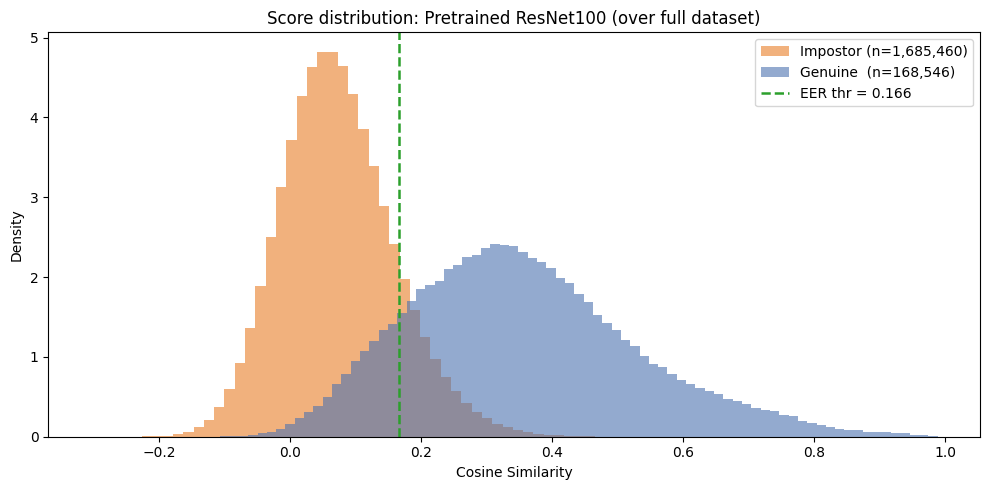

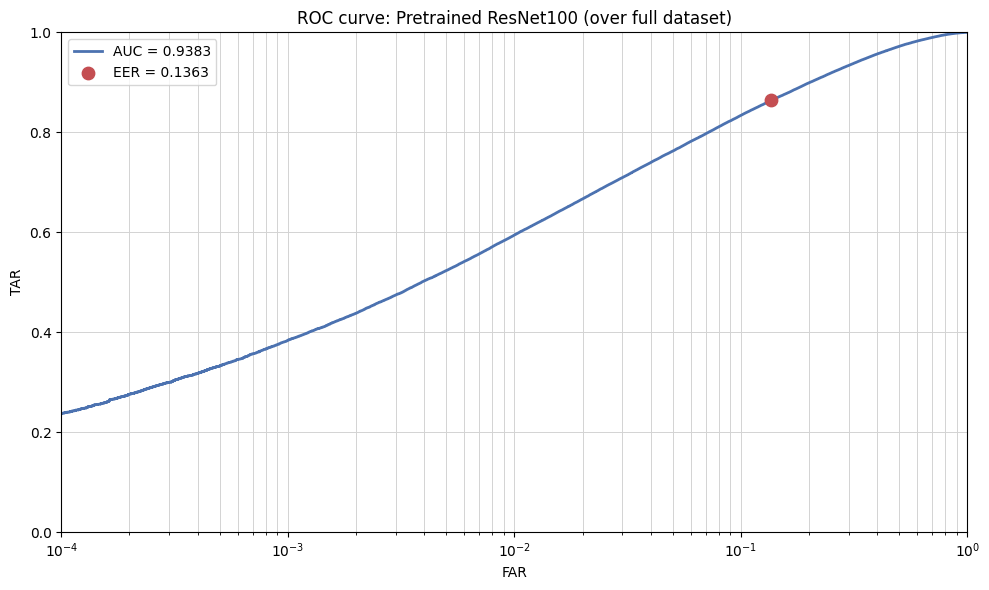

In [77]:
pairs = build_pairs(df, impostor_ratio=10, seed=42)
scores, labels, sid_a, sid_b = score_pairs(pairs, emb_pretrained)
m = compute_metrics(scores, labels, sid_a, sid_b)

print(f'Genuine:    {labels.sum():,}  |  Impostor: {(labels==0).sum():,}')
print(f'AUC:        {m["AUC"]}')
print(f'Macro-AUC:  {m["macro_AUC"]}  (over {m["macro_n"]:,} sitters)')
print(f'EER:        {m["EER"]}  (threshold = {m["EER_thr"]})')
print(f'TAR@1%:     {m["TAR@1%"]}')
print(f'TAR@0.1%:   {m["TAR@0.1%"]}')

genuine  = scores[labels == 1]
impostor = scores[labels == 0]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(impostor, bins=80, density=True, alpha=0.6, color='#E87D27', label=f'Impostor (n={len(impostor):,})')
ax.hist(genuine,  bins=80, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine  (n={len(genuine):,})')
ax.axvline(m['EER_thr'], color='#2CA02C', linestyle='--', lw=1.8, label=f'EER thr = {m["EER_thr"]:.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Score distribution: Pretrained ResNet100 (over full dataset)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(m['_fpr'], m['_tpr'], color='#4C72B0', lw=2, label=f'AUC = {m["AUC"]}')
ax.scatter([m['EER']], [1 - m['EER']], color='#C44E52', s=80, zorder=5, label=f'EER = {m["EER"]}')
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curve: Pretrained ResNet100 (over full dataset)')
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.legend()
plt.tight_layout()
plt.show()

---
## EXP1: Stratified by medium group (pretrained model)

Pairs built — genuine: 35,044  impostor: 350,440  ratio: 1:10
Pairs built — genuine: 12,190  impostor: 121,900  ratio: 1:10
Pairs built — genuine: 24,670  impostor: 246,700  ratio: 1:10
Pairs built — genuine: 3,061  impostor: 30,610  ratio: 1:10
Pairs built — genuine: 513  impostor: 5,130  ratio: 1:10
Pairs built — genuine: 593  impostor: 5,930  ratio: 1:10
Pairs built — genuine: 43  impostor: 430  ratio: 1:10


,Medium,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings,"9,613","4,416",0.9544,0.9579,0.1144,0.6551,0.4474
1,Photographs,"7,557","2,978",0.9790,0.9724,0.0613,0.8916,0.8201
2,Prints,"4,698","1,547",0.9121,0.9615,0.1669,0.4916,0.2909
3,Drawings,"3,644","2,311",0.9273,0.9254,0.1484,0.5449,0.3290
4,Portrait miniatures,"1,036",769,0.8981,0.9333,0.1890,0.5010,0.3372
5,Sculpture,491,302,0.8484,0.9085,0.2322,0.3153,0.1703
6,Other,298,260,0.8127,0.7940,0.2581,0.0000,0.0000


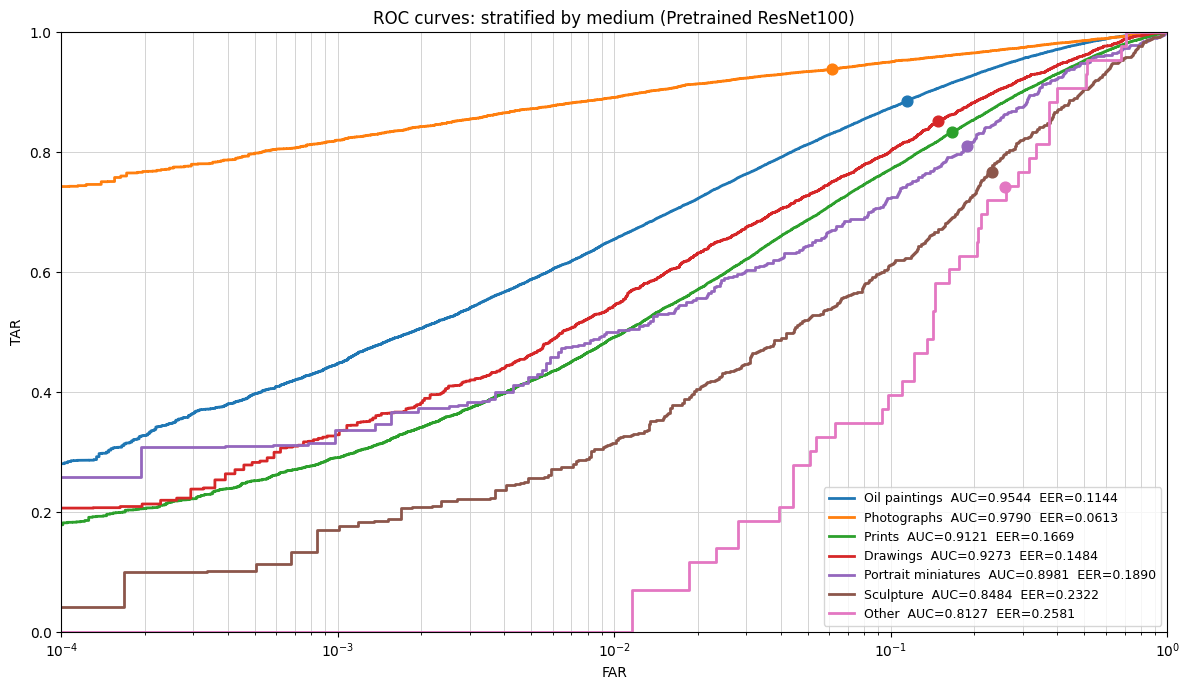

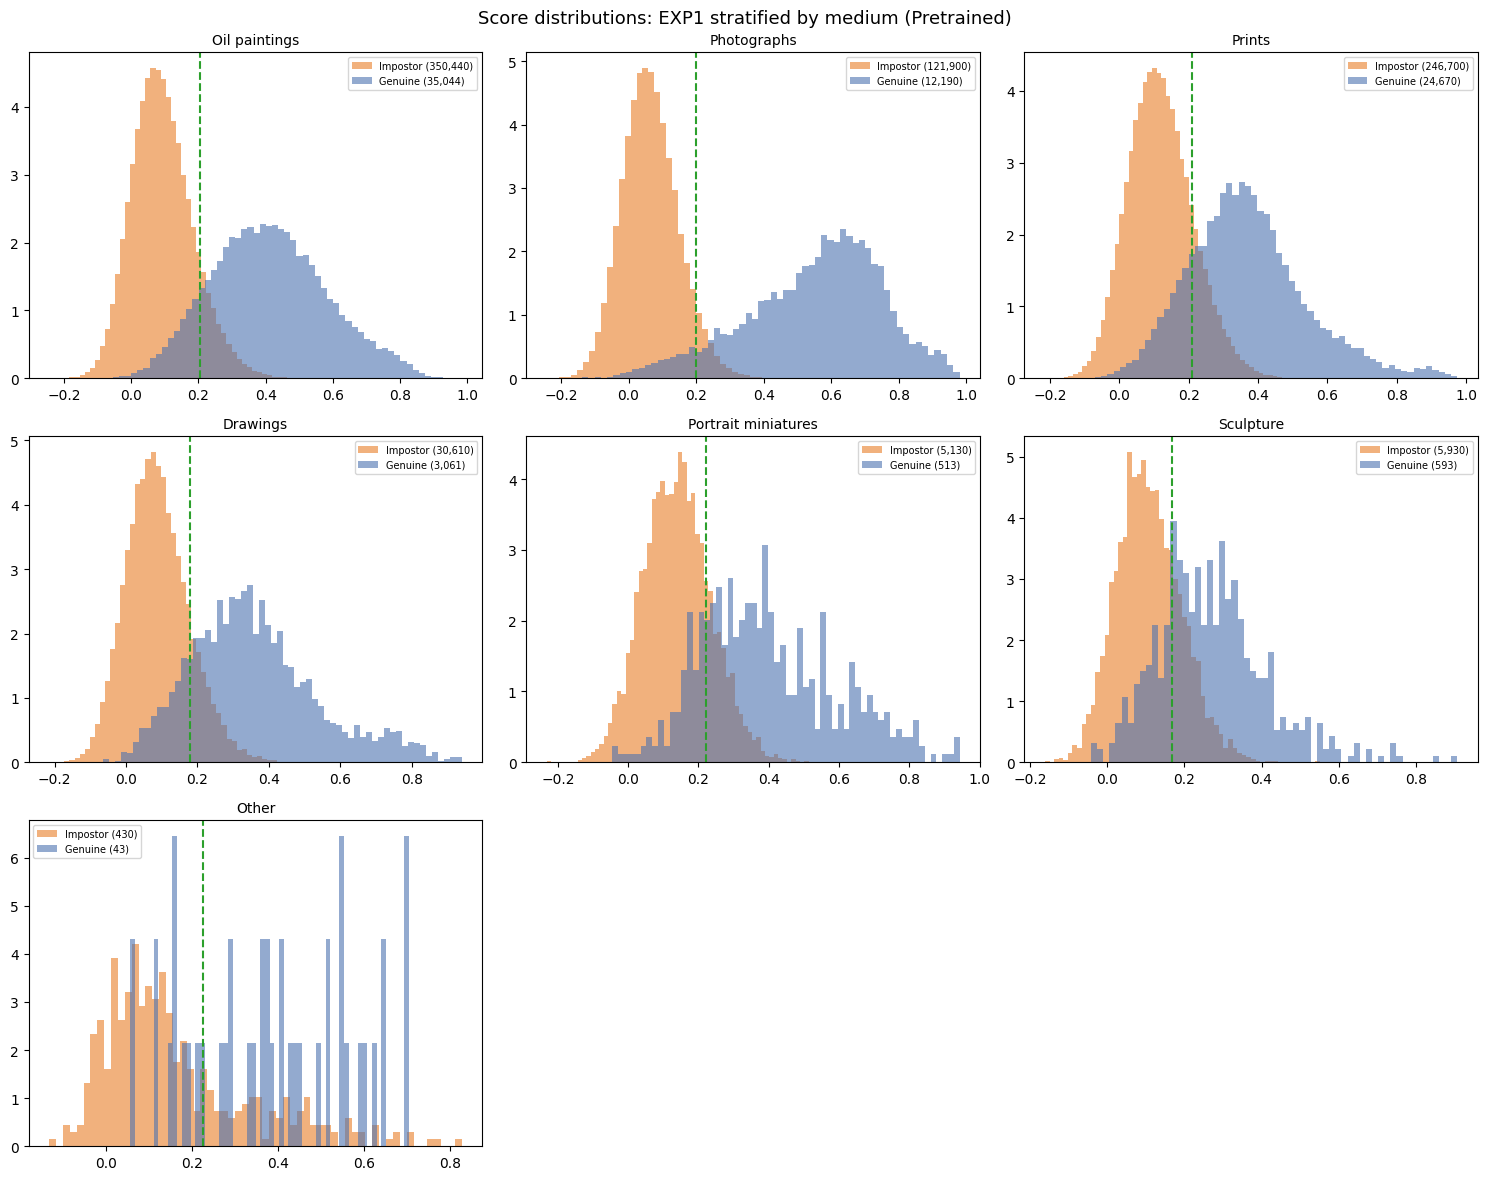

In [78]:
media = (df.groupby('medium_group')['lref']
           .count()
           .sort_values(ascending=False)
           .index.tolist())

rows, roc_entries = [], []

for medium in media:
    subset = df[df['medium_group'] == medium]
    if subset['sitter_id'].nunique() < 2:
        continue
    pairs          = build_pairs(subset, impostor_ratio=10, seed=42)
    sc, lb, sa, sb = score_pairs(pairs, emb_pretrained)
    m              = compute_metrics(sc, lb, sa, sb)
    rows.append({
        'Medium':    medium,
        'Portraits': len(subset),
        'Sitters':   subset['sitter_id'].nunique(),
        'AUC':       m['AUC'],
        'Macro-AUC': m['macro_AUC'],
        'EER':       m['EER'],
        'TAR@1%':    m['TAR@1%'],
        'TAR@0.1%':  m['TAR@0.1%'],
    })
    roc_entries.append({'label': medium, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                        'auc': m['AUC'], 'eer': m['EER'],
                        'scores': m['_scores'], 'labels': m['_labels'],
                        'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'Portraits': '{:,}', 'Sitters': '{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2,
            label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: stratified by medium (Pretrained ResNet100)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

n = len(roc_entries)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions: EXP1 stratified by medium (Pretrained)', fontsize=13)
plt.tight_layout()
plt.show()

---
## EXP2 Cross-medium genuine pairs (pretrained model)

  Cross-medium (Oil paintings × Prints) — shared sitters: 937  genuine: 43,234  impostor: 432,340
  Cross-medium (Oil paintings × Drawings) — shared sitters: 1,357  genuine: 8,894  impostor: 88,940
  Cross-medium (Oil paintings × Photographs) — shared sitters: 614  genuine: 5,315  impostor: 53,150
  Cross-medium (Drawings × Prints) — shared sitters: 448  genuine: 4,961  impostor: 49,610
  Cross-medium (Photographs × Prints) — shared sitters: 152  genuine: 3,496  impostor: 34,960
  Cross-medium (Drawings × Photographs) — shared sitters: 362  genuine: 2,118  impostor: 21,180


,Combination,Genuine,Impostor,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings x Prints,"43,234","432,340",0.9295,0.9397,0.1465,0.5360,0.2980
1,Oil paintings x Drawings,"8,894","88,940",0.8941,0.9181,0.1903,0.4530,0.2702
2,Oil paintings x Photographs,"5,315","53,150",0.9546,0.9529,0.1136,0.7029,0.5281
3,Drawings x Prints,"4,961","49,610",0.8837,0.9323,0.2026,0.4080,0.2373
4,Photographs x Prints,"3,496","34,960",0.9546,0.9599,0.1104,0.7100,0.5503
5,Drawings x Photographs,"2,118","21,180",0.9304,0.9250,0.1501,0.5770,0.3952


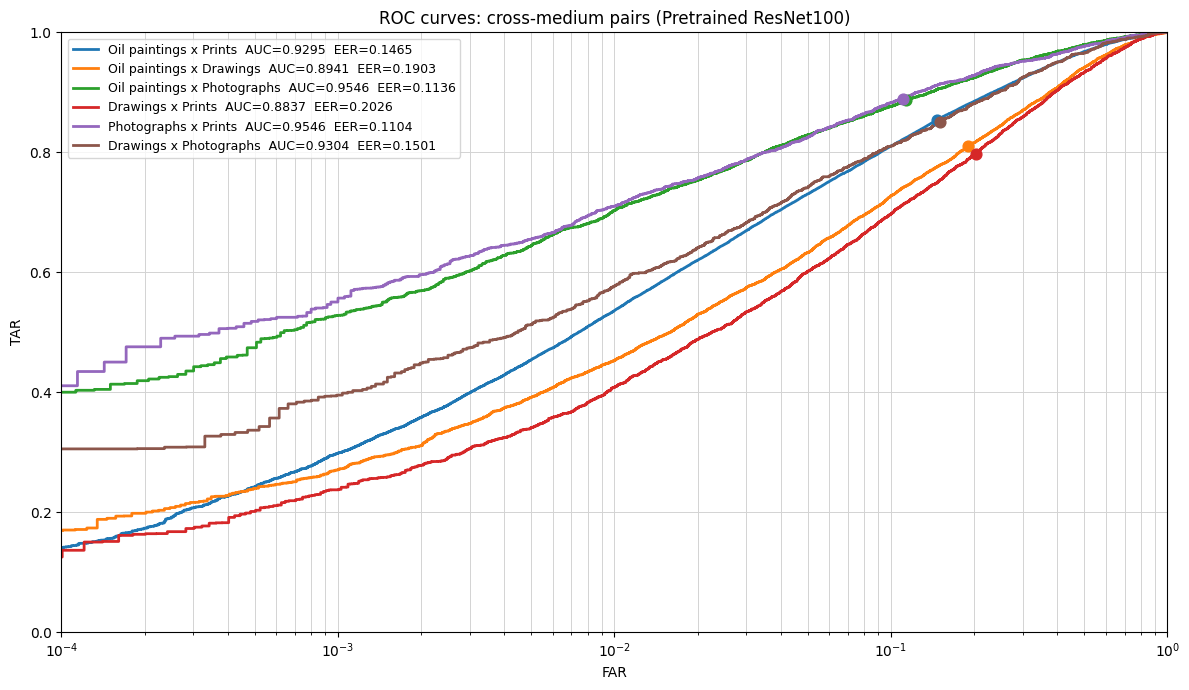

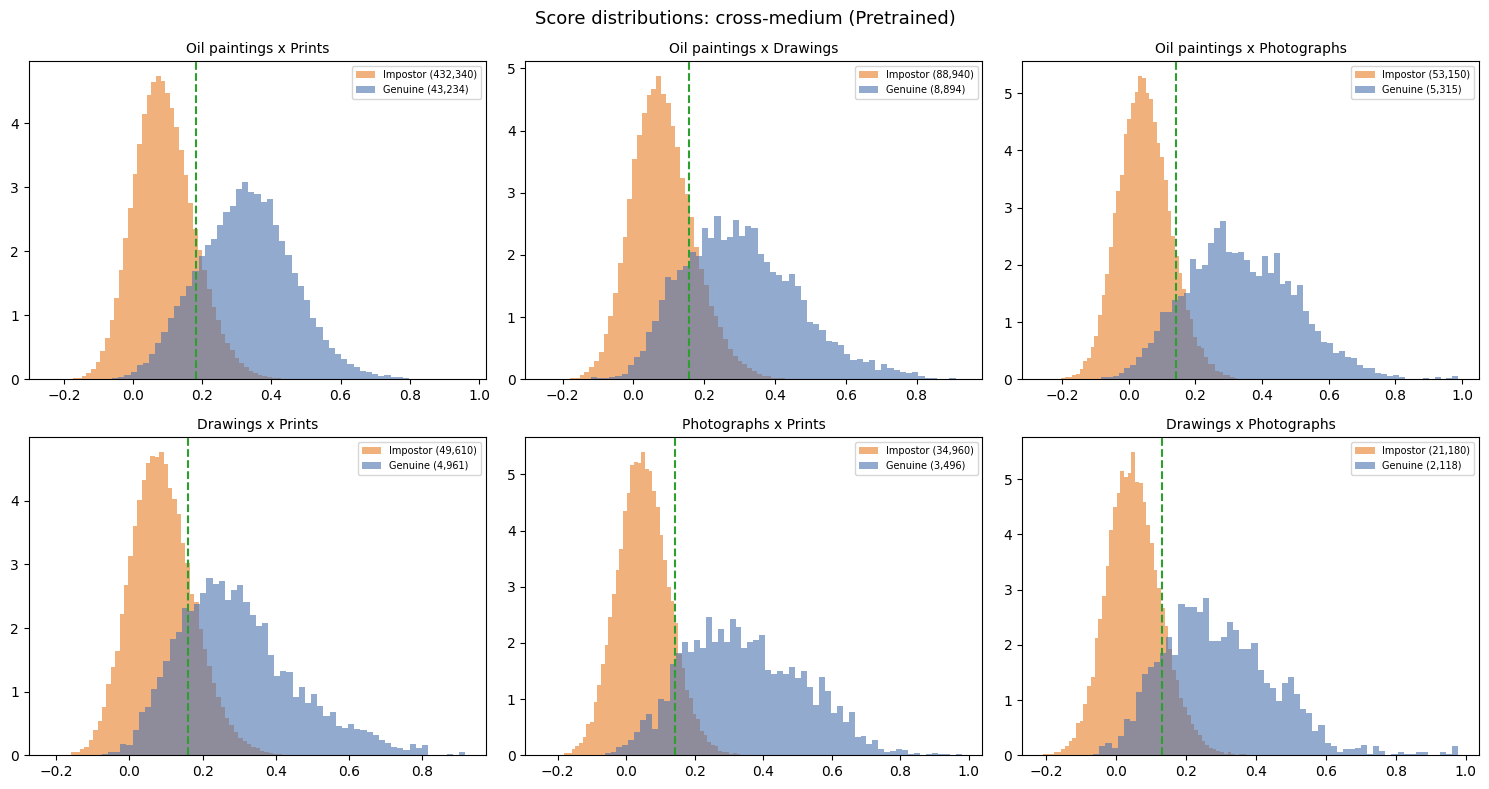

In [79]:
combinations = [
    ('Oil paintings', 'Prints'),
    ('Oil paintings', 'Drawings'),
    ('Oil paintings', 'Photographs'),
    ('Drawings',      'Prints'),
    ('Photographs',   'Prints'),
    ('Drawings',      'Photographs'),
]

rows, roc_entries = [], []

for med_a, med_b in combinations:
    pairs          = build_cross_medium_pairs(df, 'medium_group', med_a, med_b,
                                              impostor_ratio=10, seed=42)
    if not pairs:
        continue
    sc, lb, sa, sb = score_pairs(pairs, emb_pretrained)
    m              = compute_metrics(sc, lb, sa, sb)
    label          = f'{med_a} x {med_b}'
    rows.append({
        'Combination': label,
        'Genuine':     int(lb.sum()),
        'Impostor':    int((lb == 0).sum()),
        'AUC':         m['AUC'],
        'Macro-AUC':   m['macro_AUC'],
        'EER':         m['EER'],
        'TAR@1%':      m['TAR@1%'],
        'TAR@0.1%':    m['TAR@0.1%'],
    })
    roc_entries.append({'label': label, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                        'auc': m['AUC'], 'eer': m['EER'],
                        'scores': m['_scores'], 'labels': m['_labels'],
                        'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'Genuine': '{:,}', 'Impostor': '{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2,
            label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: cross-medium pairs (Pretrained ResNet100)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

n = len(roc_entries)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions: cross-medium (Pretrained)', fontsize=13)
plt.tight_layout()
plt.show()

---
## EXP3: Fine-tuned model (all media), stratified by medium group
Evaluation on **test sitters only** (df_test). Includes pretrained baseline on same test split for fair comparison, plus delta table.

Pairs built — genuine: 2,696  impostor: 26,960  ratio: 1:10
Pairs built — genuine: 2,179  impostor: 21,790  ratio: 1:10
Pairs built — genuine: 1,680  impostor: 16,800  ratio: 1:10
Pairs built — genuine: 958  impostor: 9,580  ratio: 1:10
Pairs built — genuine: 99  impostor: 990  ratio: 1:10
Pairs built — genuine: 34  impostor: 340  ratio: 1:10
Pairs built — genuine: 8  impostor: 80  ratio: 1:10
Pairs built — genuine: 2,696  impostor: 26,960  ratio: 1:10
Pairs built — genuine: 2,179  impostor: 21,790  ratio: 1:10
Pairs built — genuine: 1,680  impostor: 16,800  ratio: 1:10
Pairs built — genuine: 958  impostor: 9,580  ratio: 1:10
Pairs built — genuine: 99  impostor: 990  ratio: 1:10
Pairs built — genuine: 34  impostor: 340  ratio: 1:10
Pairs built — genuine: 8  impostor: 80  ratio: 1:10

### Pretrained (test split)


,Medium,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings,"1,751",877,0.9553,0.9543,0.1135,0.6628,0.4800
1,Photographs,"1,462",591,0.9719,0.9705,0.0689,0.8761,0.8137
2,Prints,807,302,0.9519,0.9634,0.1173,0.6387,0.4810
3,Drawings,766,482,0.9486,0.9432,0.1220,0.5209,0.2349
4,Portrait miniatures,209,149,0.9121,0.9417,0.1813,0.5152,0.3131
5,Sculpture,87,68,0.8565,0.9076,0.2015,0.3235,0.2353
6,Other,54,46,0.8031,0.8214,0.2750,0.0000,0.0000



### EXP3 fine-tuned


,Medium,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings,"1,751",877,0.9618,0.9442,0.0979,0.7133,0.4852
1,Photographs,"1,462",591,0.9724,0.9693,0.0799,0.8229,0.7210
2,Prints,807,302,0.9562,0.9669,0.1126,0.6488,0.4524
3,Drawings,766,482,0.9499,0.9437,0.1180,0.5532,0.2630
4,Portrait miniatures,209,149,0.9294,0.9524,0.1626,0.5253,0.2828
5,Sculpture,87,68,0.8651,0.8872,0.2691,0.3235,0.1765
6,Other,54,46,0.8391,0.8624,0.3250,0.0000,0.0000



### Delta: EXP3 fine-tuned − Pretrained (test split)


,Medium,ΔAUC,ΔMacro-AUC,ΔEER,ΔTAR@1%,ΔTAR@0.1%
0,Oil paintings,+0.0065,-0.0101,-0.0156,+0.0505,+0.0052
1,Photographs,+0.0005,-0.0012,+0.0110,-0.0532,-0.0927
2,Prints,+0.0043,+0.0035,-0.0047,+0.0101,-0.0286
3,Drawings,+0.0013,+0.0005,-0.0040,+0.0323,+0.0281
4,Portrait miniatures,+0.0173,+0.0107,-0.0187,+0.0101,-0.0303
5,Sculpture,+0.0086,-0.0204,+0.0676,+0.0000,-0.0588
6,Other,+0.0360,+0.0410,+0.0500,+0.0000,+0.0000


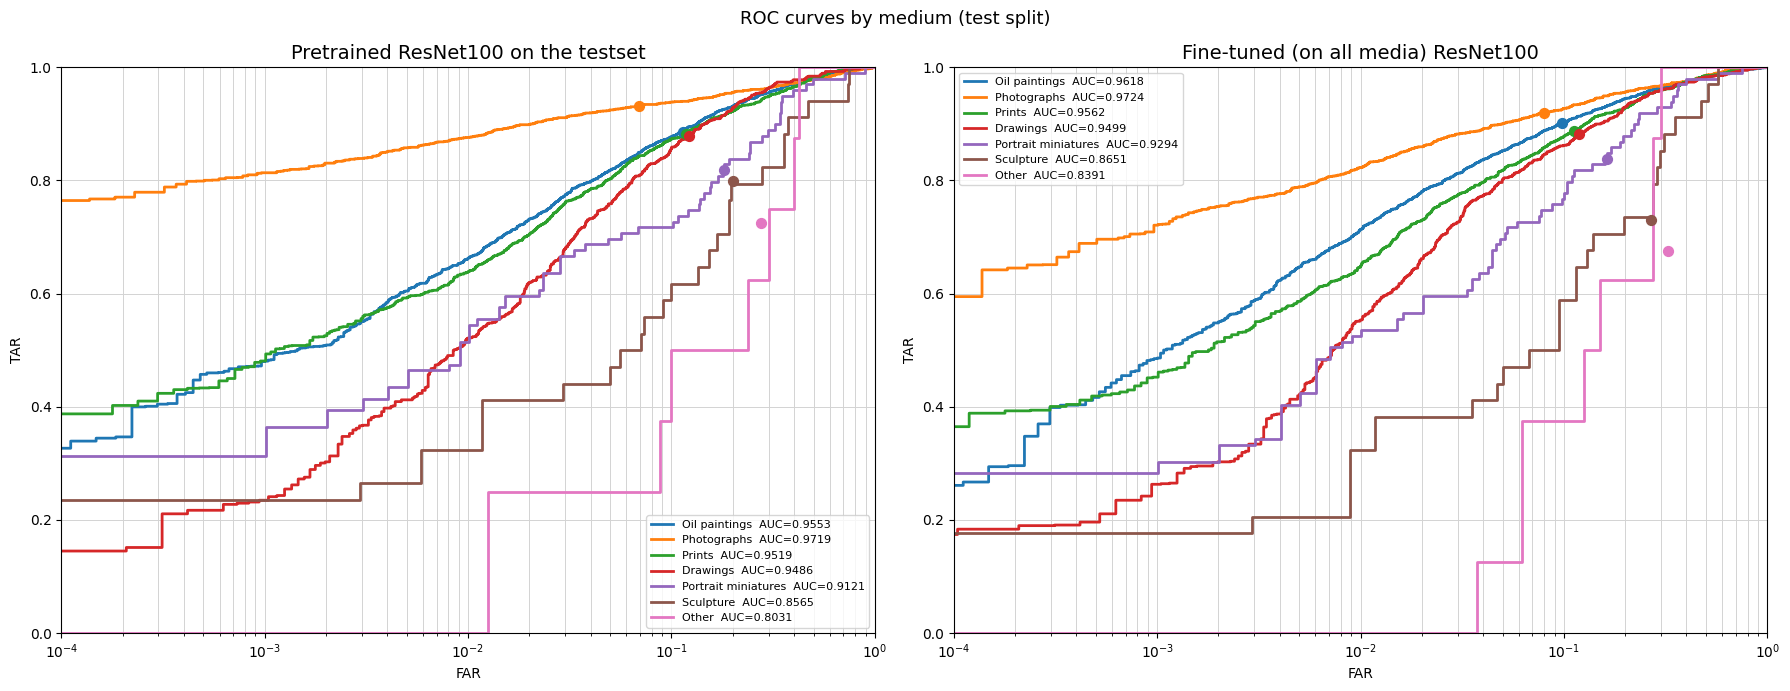

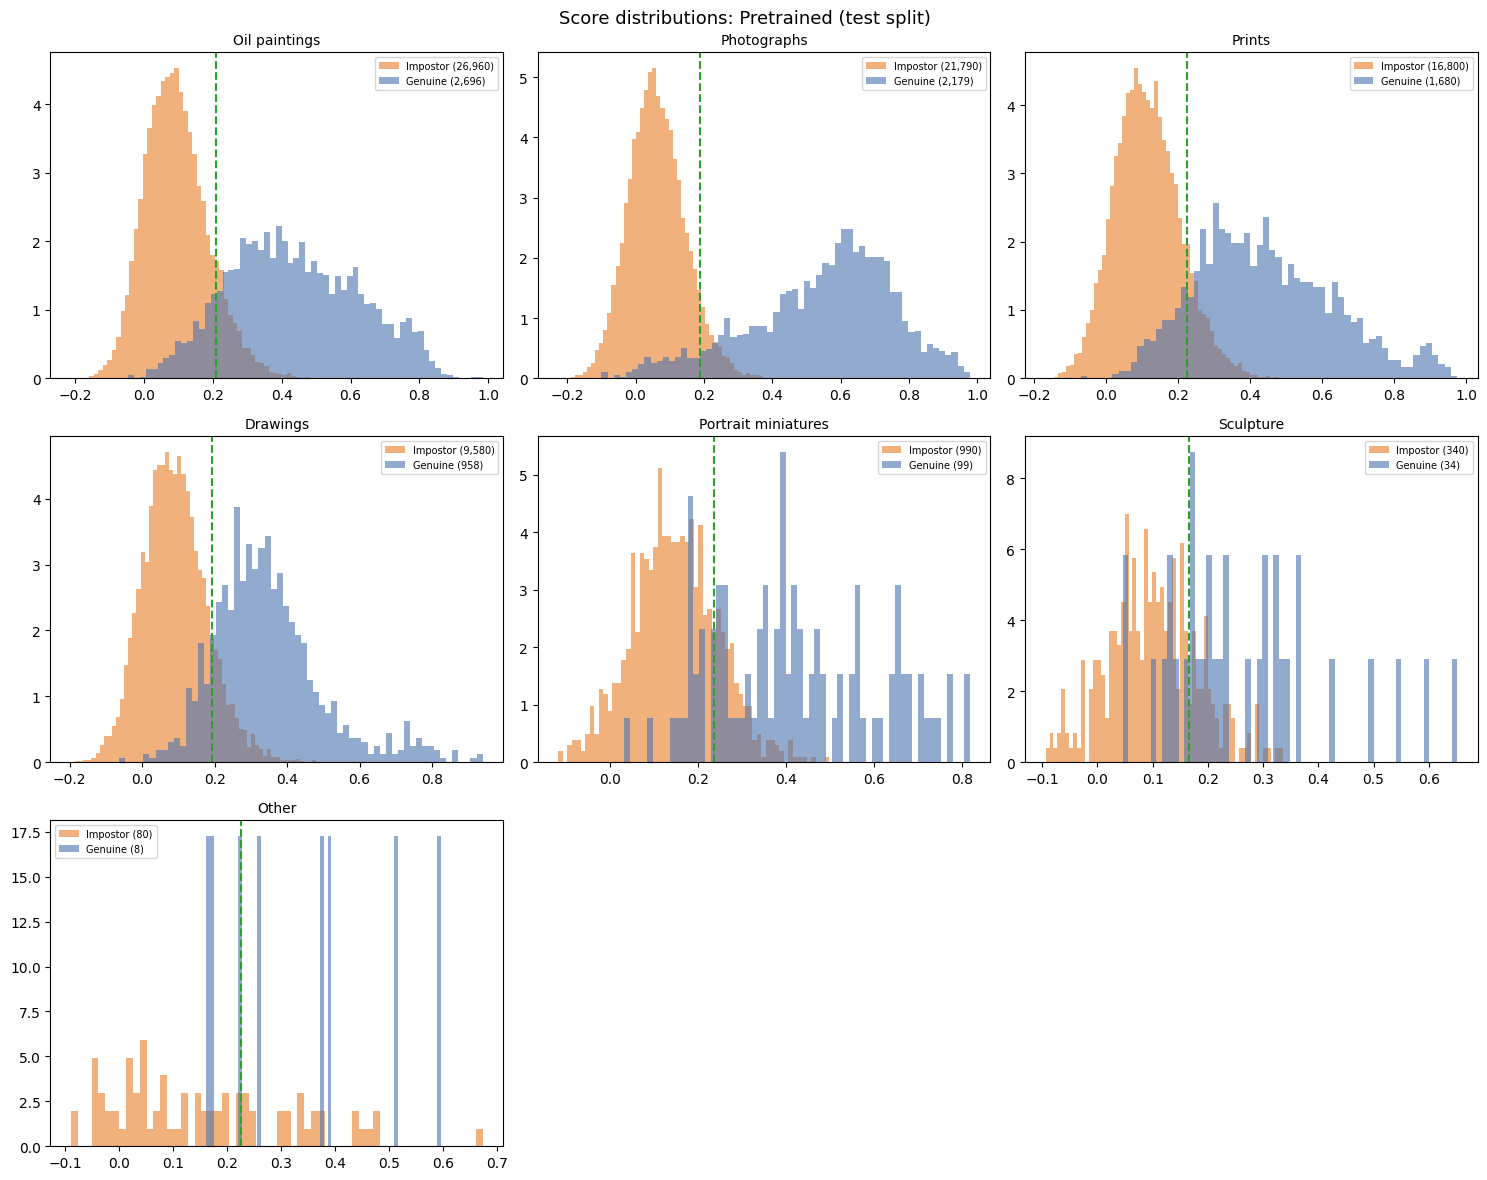

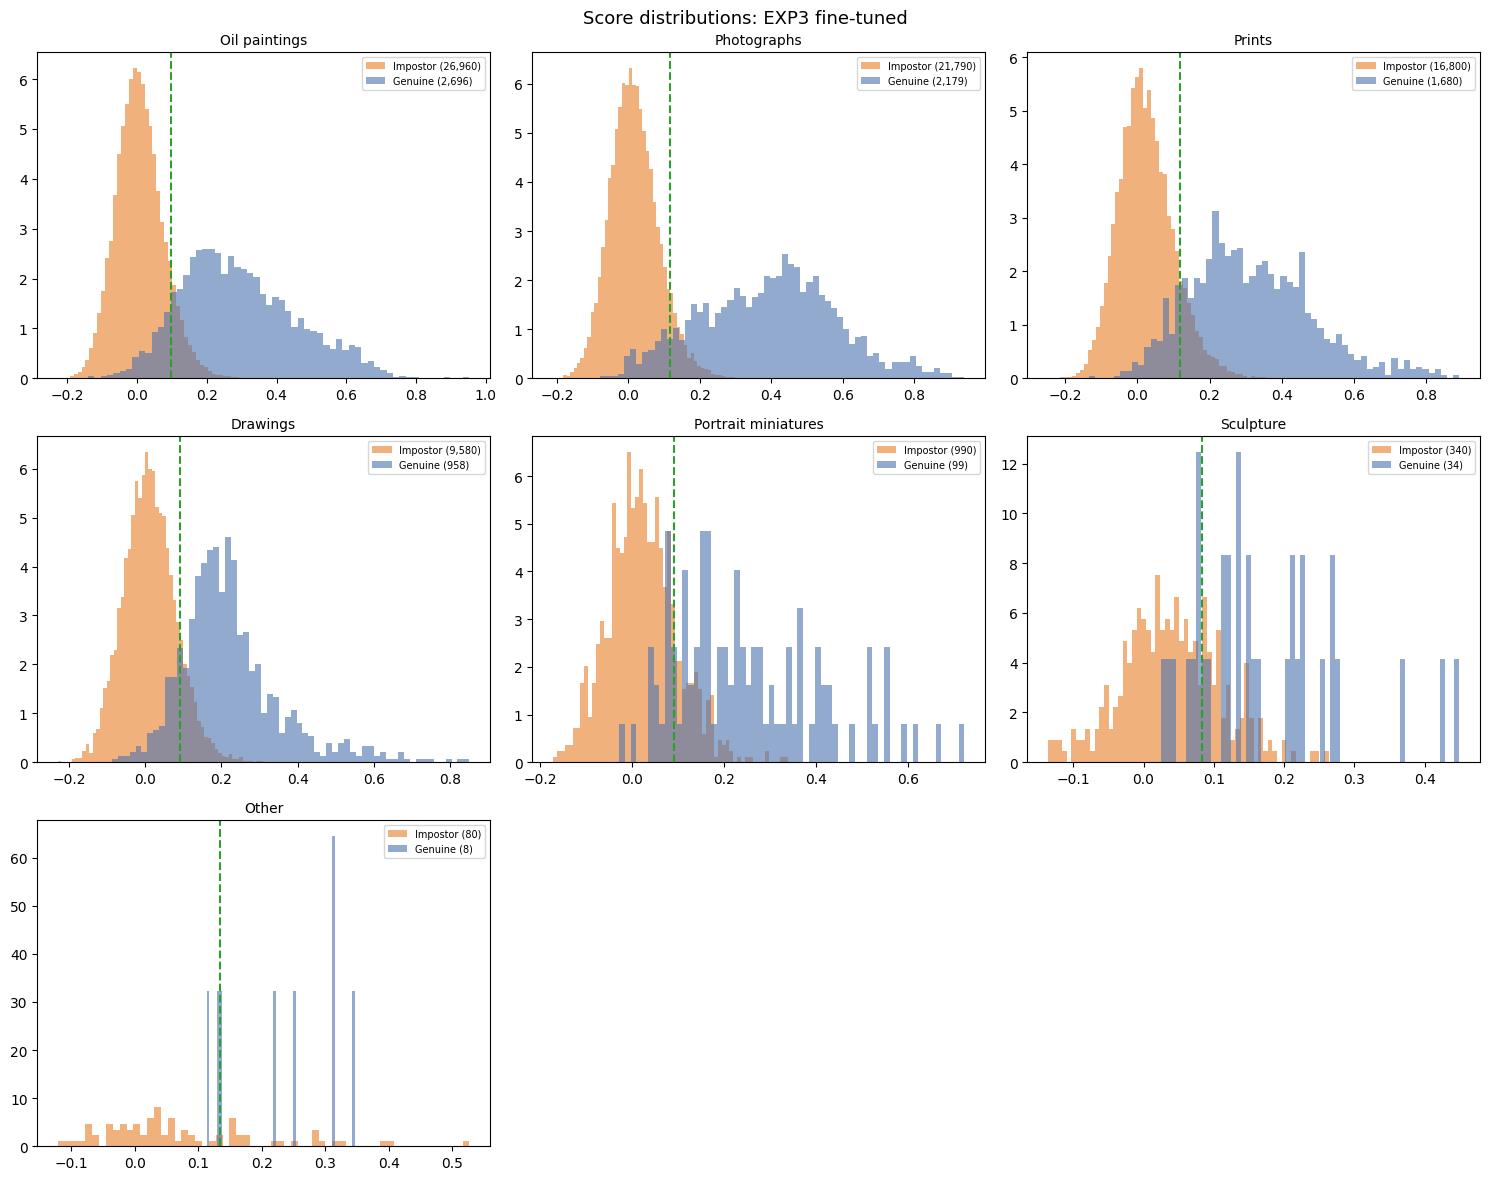

In [80]:
media_test = (df_test.groupby('medium_group')['lref']
                     .count()
                     .sort_values(ascending=False)
                     .index.tolist())

results_by_model = {}

for model_name, embeddings in [('Pretrained (test split)', emb_pretrained),
                                ('EXP3 fine-tuned',        emb_exp3)]:
    rows, roc_entries = [], []
    for medium in media_test:
        subset = df_test[df_test['medium_group'] == medium]
        if subset['sitter_id'].nunique() < 2:
            continue
        pairs          = build_pairs(subset, impostor_ratio=10, seed=42)
        sc, lb, sa, sb = score_pairs(pairs, embeddings)
        m              = compute_metrics(sc, lb, sa, sb)
        rows.append({
            'Medium':    medium,
            'Portraits': len(subset),
            'Sitters':   subset['sitter_id'].nunique(),
            'AUC':       m['AUC'],
            'Macro-AUC': m['macro_AUC'],
            'EER':       m['EER'],
            'TAR@1%':    m['TAR@1%'],
            'TAR@0.1%':  m['TAR@0.1%'],
        })
        roc_entries.append({'label': medium, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                            'auc': m['AUC'], 'eer': m['EER'],
                            'scores': m['_scores'], 'labels': m['_labels'],
                            'eer_thr': m['EER_thr']})
    results_by_model[model_name] = {'rows': rows, 'roc': roc_entries}

# Tables:
for model_name, data in results_by_model.items():
    print(f'\n### {model_name}')
    display(pd.DataFrame(data['rows']).style.format({
        'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
        'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
        'Portraits': '{:,}', 'Sitters': '{:,}',
    }))

# Delta table: EXP3 fine-tuned vs pretrained baseline
base_rows = {r['Medium']: r for r in results_by_model['Pretrained (test split)']['rows']}
ft_rows   = {r['Medium']: r for r in results_by_model['EXP3 fine-tuned']['rows']}
delta_rows = []
for medium in base_rows:
    if medium not in ft_rows:
        continue
    b, f = base_rows[medium], ft_rows[medium]
    delta_rows.append({
        'Medium':       medium,
        'ΔAUC':         round(f['AUC']       - b['AUC'],       4),
        'ΔMacro-AUC':   round((f['Macro-AUC'] or 0) - (b['Macro-AUC'] or 0), 4),
        'ΔEER':         round(f['EER']       - b['EER'],       4),
        'ΔTAR@1%':      round(f['TAR@1%']    - b['TAR@1%'],    4),
        'ΔTAR@0.1%':    round(f['TAR@0.1%']  - b['TAR@0.1%'],  4),
    })
print('\n### Delta: EXP3 fine-tuned − Pretrained (test split)')
display(pd.DataFrame(delta_rows).style.format({
    'ΔAUC': '{:+.4f}', 'ΔMacro-AUC': '{:+.4f}', 'ΔEER': '{:+.4f}',
    'ΔTAR@1%': '{:+.4f}', 'ΔTAR@0.1%': '{:+.4f}',
}))

# Combined ROC curves (both models, all media)
colors = plt.cm.tab10.colors
titles = ['Pretrained ResNet100 on the testset', 'Fine-tuned (on all media) ResNet100']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, title, (model_name, data) in zip(axes, titles, results_by_model.items()):
    for i, e in enumerate(data['roc']):
        c = colors[i % 10]
        ax.plot(e['fpr'], e['tpr'], color=c, lw=2,
                label=f"{e['label']}  AUC={e['auc']:.4f}")
        ax.scatter([e['eer']], [1 - e['eer']], color=c, s=50, zorder=5)
    ax.set_xscale('log')
    ax.set_xlim([1e-4, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, which='both', color='lightgrey', lw=0.7)
    ax.set_xlabel('FAR')
    ax.set_ylabel('TAR')
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=8)
plt.suptitle('ROC curves by medium (test split)', fontsize=13)
plt.tight_layout()
plt.show()

# Score distribution grids
for model_name, data in results_by_model.items():
    entries = data['roc']
    n = len(entries)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()
    for i, e in enumerate(entries):
        ax  = axes[i]
        gen = e['scores'][e['labels'] == 1]
        imp = e['scores'][e['labels'] == 0]
        ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
        ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
        ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
        ax.set_title(e['label'], fontsize=10)
        ax.legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Score distributions: {model_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## EXP4: Oil-paintings-only fine-tuning vs pretrained vs EXP3
Evaluation on **oil paintings, test sitters only**. Compares all three models on the same subset.

Pairs built — genuine: 2,696  impostor: 26,960  ratio: 1:10


,Model,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Pretrained,"1,751",877,0.9553,0.9543,0.1135,0.6628,0.4800
1,EXP3 (all media),"1,751",877,0.9618,0.9442,0.0979,0.7133,0.4852
2,EXP4 (oil only),"1,751",877,0.9460,0.9327,0.1245,0.6595,0.4648


,Model,ΔAUC,ΔMacro-AUC,ΔEER,ΔTAR@1%,ΔTAR@0.1%
0,EXP3 (all media) − Pretrained,+0.0065,-0.0101,-0.0156,+0.0505,+0.0052
1,EXP4 (oil only) − Pretrained,-0.0093,-0.0216,+0.0110,-0.0033,-0.0152


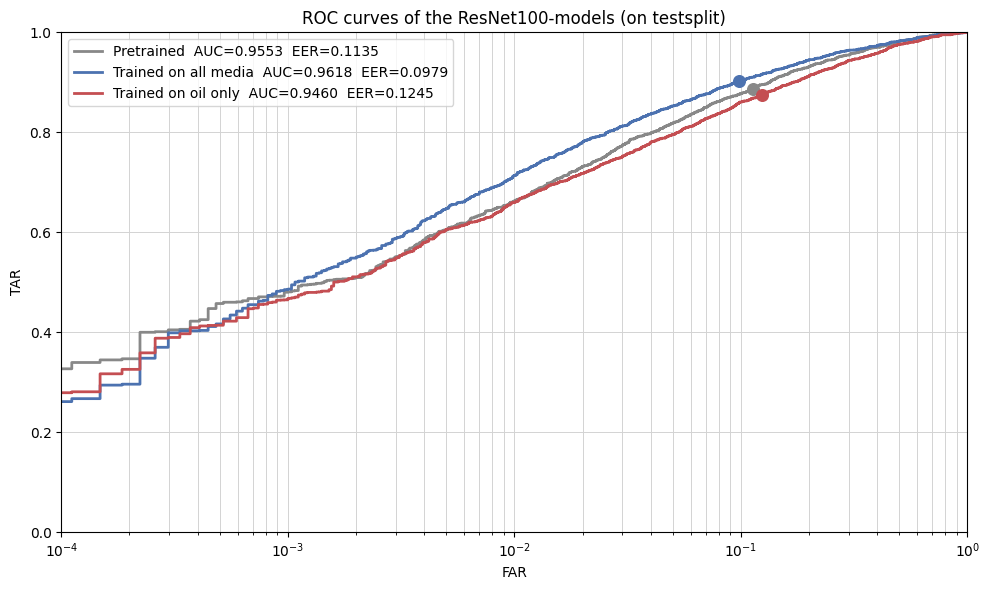

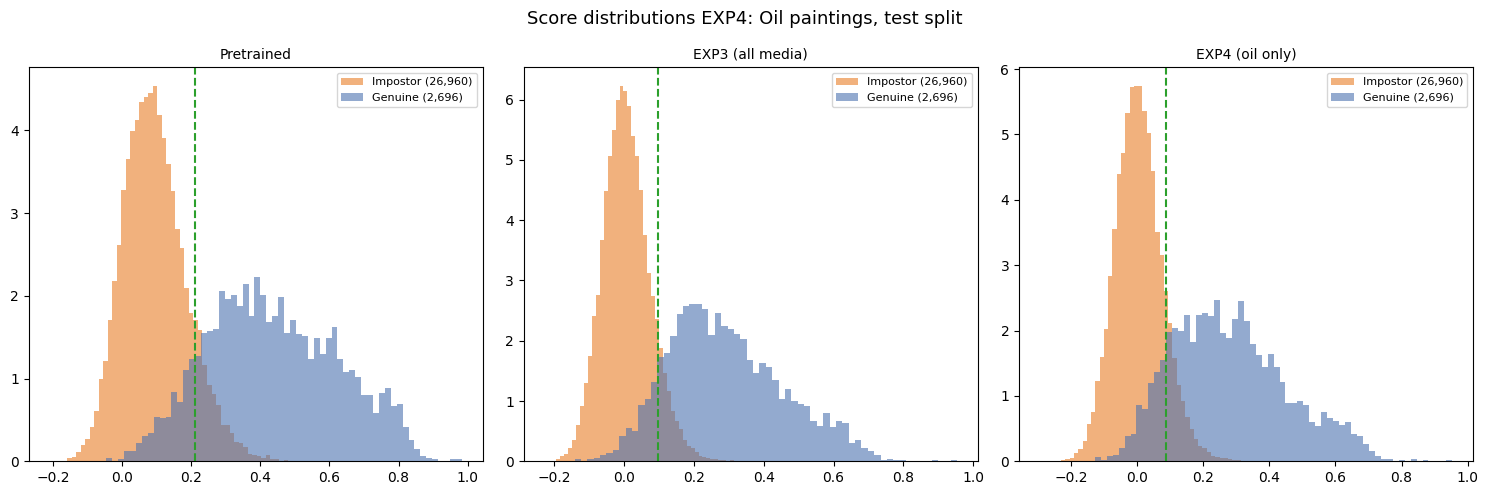

In [81]:
subset_oil = df_test[df_test['medium_group'] == 'Oil paintings']
pairs_oil  = build_pairs(subset_oil, impostor_ratio=10, seed=42)

models = [
    ('Pretrained',    emb_pretrained),
    ('EXP3 (all media)', emb_exp3),
    ('EXP4 (oil only)',  emb_exp4),
]

results_exp4 = {}
for model_name, embeddings in models:
    sc, lb, sa, sb       = score_pairs(pairs_oil, embeddings)
    m                    = compute_metrics(sc, lb, sa, sb)
    results_exp4[model_name] = m

# Metric table
rows = []
for model_name, m in results_exp4.items():
    rows.append({
        'Model':      model_name,
        'Portraits':  len(subset_oil),
        'Sitters':    subset_oil['sitter_id'].nunique(),
        'AUC':        m['AUC'],
        'Macro-AUC':  m['macro_AUC'],
        'EER':        m['EER'],
        'TAR@1%':     m['TAR@1%'],
        'TAR@0.1%':   m['TAR@0.1%'],
    })
display(pd.DataFrame(rows).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'Portraits': '{:,}', 'Sitters': '{:,}',
}))

# Delta table vs pretrained
base = results_exp4['Pretrained']
delta_rows = []
for model_name in ['EXP3 (all media)', 'EXP4 (oil only)']:
    f = results_exp4[model_name]
    delta_rows.append({
        'Model':      f'{model_name} − Pretrained',
        'ΔAUC':       round(f['AUC']       - base['AUC'],       4),
        'ΔMacro-AUC': round((f['macro_AUC'] or 0) - (base['macro_AUC'] or 0), 4),
        'ΔEER':       round(f['EER']       - base['EER'],       4),
        'ΔTAR@1%':    round(f['TAR@1%']    - base['TAR@1%'],    4),
        'ΔTAR@0.1%':  round(f['TAR@0.1%']  - base['TAR@0.1%'],  4),
    })
display(pd.DataFrame(delta_rows).style.format({
    'ΔAUC': '{:+.4f}', 'ΔMacro-AUC': '{:+.4f}', 'ΔEER': '{:+.4f}',
    'ΔTAR@1%': '{:+.4f}', 'ΔTAR@0.1%': '{:+.4f}',
}))

# #Combined ROC curve
# colors_map = {'Pretrained': '#888888', 'EXP3 (all media)': '#4C72B0', 'EXP4 (oil only)': '#C44E52'}
# fig, ax = plt.subplots(figsize=(10, 6))
# for model_name, m in results_exp4.items():
#     c = colors_map[model_name]
#     ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
#             label=f"{model_name}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
#     ax.scatter([m['EER']], [1 - m['EER']], color=c, s=70, zorder=5)
# ax.set_xscale('log')
# ax.set_xlim([1e-4, 1])
# ax.set_ylim([0, 1])
# ax.grid(True, which='both', color='lightgrey', lw=0.7)
# ax.set_xlabel('FAR')
# ax.set_ylabel('TAR')
# ax.set_title('ROC curves EXP4: Oil paintings, test split (3 models)')
# ax.legend(fontsize=10)
# plt.tight_layout()
# plt.show()

#Combined ROC curve
colors_map = {'Pretrained': '#888888', 'EXP3 (all media)': '#4C72B0', 'EXP4 (oil only)': '#C44E52'}
legend_labels = {
    'Pretrained': 'Pretrained',
    'EXP3 (all media)': 'Trained on all media',
    'EXP4 (oil only)': 'Trained on oil only',
}

fig, ax = plt.subplots(figsize=(10, 6))
for model_name, m in results_exp4.items():
    c = colors_map[model_name]
    label = legend_labels[model_name]
    ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
            label=f"{label}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
    ax.scatter([m['EER']], [1 - m['EER']], color=c, s=70, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves of the ResNet100-models (on testsplit)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (model_name, m) in zip(axes, results_exp4.items()):
    gen = m['_scores'][m['_labels'] == 1]
    imp = m['_scores'][m['_labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
    ax.axvline(m['EER_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(model_name, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Score distributions EXP4: Oil paintings, test split', fontsize=13)
plt.tight_layout()
plt.show()

---
## Artist bias detection (pretrained model)

RQ1-B: Are similarity scores inflated for portraits by the same artist, driven by shared painterly style rather than shared identity?

### EXP5: Within-artist vs cross-artist impostor scores
For each qualifying artist (≥5 unique sitters, excluding Anoniem):

--> compare the mean cosine similarity of within-artist impostor pairs (different sitters, same artist) against cross-artist impostor pairs (different sitters, different artist).

! Each artist contributes one mean score to the distribution, so all artists weigh equally regardless of portrait count.

Qualifying artists (≥5 sitters, excl. Anoniem): 658
Portraits in filtered set: 15,645

Within-artist impostor pairs: 674,337
Cross-artist impostor pairs:  131,600


,Group,N artists,Mean,Median,Std
0,Within-artist impostors,658,0.1528,0.1459,0.0720
1,Cross-artist impostors,658,0.0734,0.0755,0.0192



Mann-Whitney U (within > cross): U=372221.0,  p=0.0000
--> Within-artist impostor scores are significantly higher (artist bias detected)


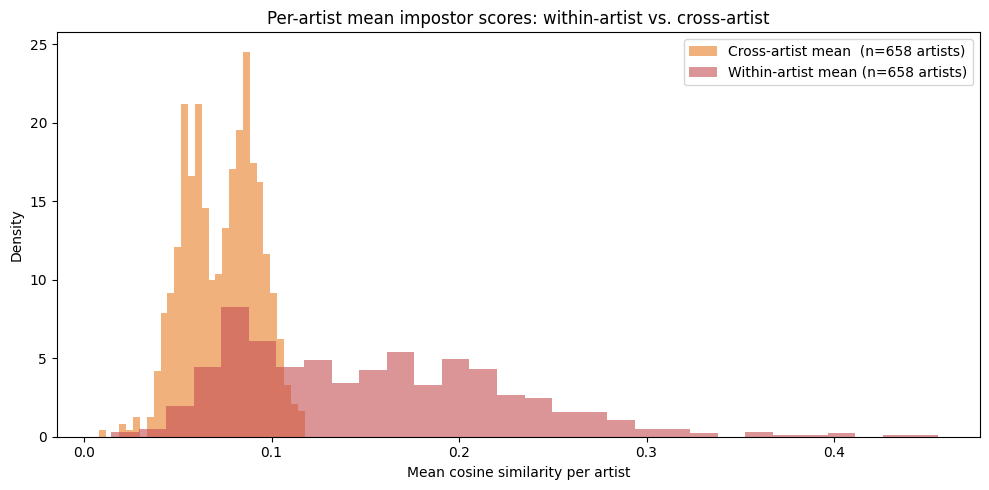

C:\Users\jenne\AppData\Local\Temp\ipykernel_40980\2472487687.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_labels, vert=True)


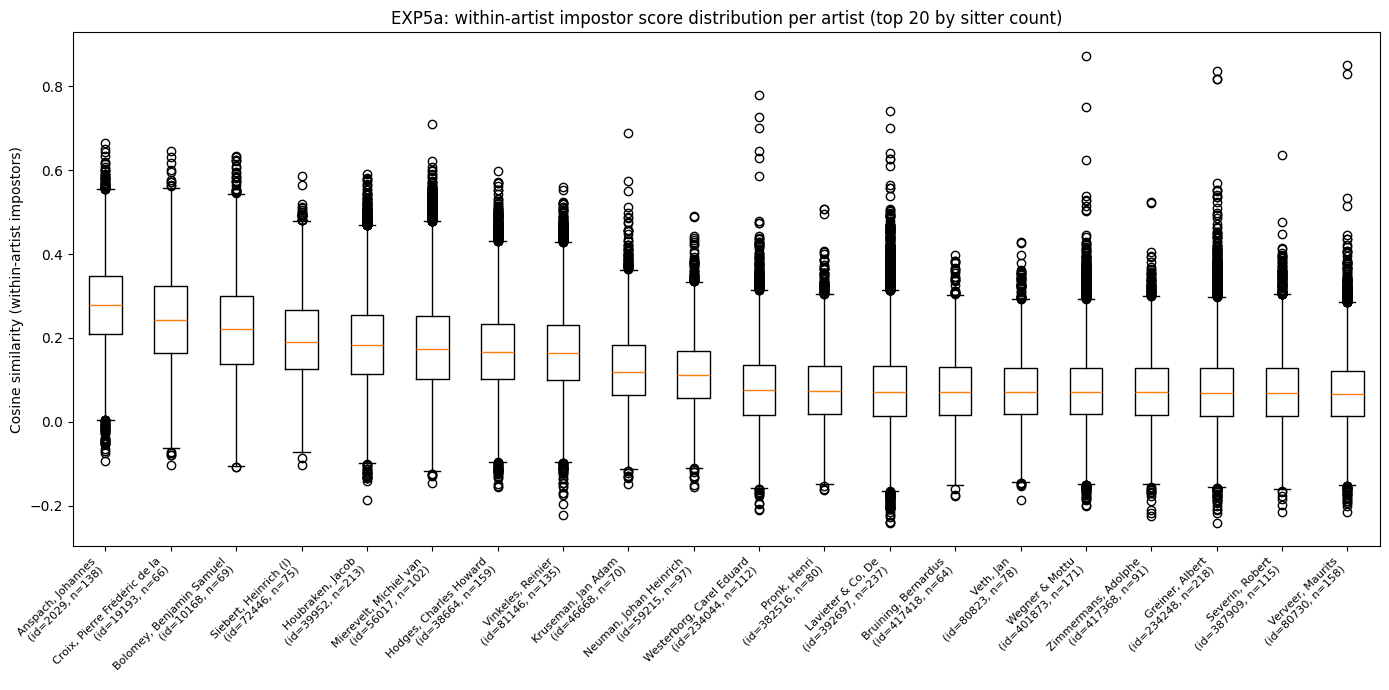

In [82]:
from itertools import combinations as itr_combinations
from scipy.stats import mannwhitneyu

MIN_SITTERS  = 5
CROSS_SAMPLE = 200  # cross-artist pairs sampled per artist

# Step 1: filter — exclude Anoniem and NaN artist_id, keep artists with ≥5 unique sitters
df5 = df[df['artist_name'] != 'Anoniem'].dropna(subset=['artist_id']).copy()
df5['artist_id'] = df5['artist_id'].astype(int)

artist_sitter_counts = df5.groupby('artist_id')['sitter_id'].nunique()
qualifying = set(artist_sitter_counts[artist_sitter_counts >= MIN_SITTERS].index)
df5 = df5[df5['artist_id'].isin(qualifying)].copy()

print(f"Qualifying artists (≥{MIN_SITTERS} sitters, excl. Anoniem): {len(qualifying):,}")
print(f"Portraits in filtered set: {len(df5):,}")

# Lookup: artist_id → list of (lref, sitter_id)
artist_portraits = {}
for artist_id, grp in df5.groupby('artist_id'):
    artist_portraits[int(artist_id)] = list(zip(
        grp['lref'].astype(str).tolist(),
        grp['sitter_id'].astype(str).tolist()
    ))

all_lrefs   = df5['lref'].astype(str).values
all_sitters = df5['sitter_id'].astype(str).values
all_artists = df5['artist_id'].astype(int).values

# Step 2: exhaustive within-artist impostor pairs
within_pairs = []
for artist_id, portraits in artist_portraits.items():
    for (la, sa), (lb, sb) in itr_combinations(portraits, 2):
        if sa != sb:
            within_pairs.append((la, lb, artist_id, sa, sb))

print(f"\nWithin-artist impostor pairs: {len(within_pairs):,}")

# Step 3: sample cross-artist impostor pairs
rng = np.random.default_rng(42)
cross_pairs = []

for artist_id, portraits in artist_portraits.items():
    my_lrefs   = np.array([p[0] for p in portraits])
    my_sitters = np.array([p[1] for p in portraits])
    other_mask    = all_artists != artist_id
    other_lrefs   = all_lrefs[other_mask]
    other_sitters = all_sitters[other_mask]

    collected, attempts = 0, 0
    while collected < CROSS_SAMPLE and attempts < CROSS_SAMPLE * 20:
        ia = rng.integers(0, len(my_lrefs))
        ib = rng.integers(0, len(other_lrefs))
        if my_sitters[ia] != other_sitters[ib]:
            cross_pairs.append((my_lrefs[ia], other_lrefs[ib], artist_id,
                                my_sitters[ia], other_sitters[ib]))
            collected += 1
        attempts += 1

print(f"Cross-artist impostor pairs:  {len(cross_pairs):,}")

# Step 4: score both sets
def score_artist_pairs(pairs, embeddings):
    scores, artists = [], []
    for la, lb, artist_id, sa, sb in pairs:
        ea = embeddings.get(la)
        eb = embeddings.get(lb)
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        artists.append(artist_id)
    return np.array(scores, dtype=np.float32), np.array(artists)

within_scores, within_artist_ids = score_artist_pairs(within_pairs, emb_pretrained)
cross_scores,  cross_artist_ids  = score_artist_pairs(cross_pairs,  emb_pretrained)

# Step 5: per-artist means
within_means = {aid: float(np.mean(within_scores[within_artist_ids == aid]))
                for aid in qualifying if (within_artist_ids == aid).sum() > 0}
cross_means  = {aid: float(np.mean(cross_scores[cross_artist_ids == aid]))
                for aid in qualifying if (cross_artist_ids == aid).sum() > 0}

common = set(within_means) & set(cross_means)
wm = np.array([within_means[a] for a in common])
cm = np.array([cross_means[a]  for a in common])

# Summary table
display(pd.DataFrame({
    'Group':        ['Within-artist impostors', 'Cross-artist impostors'],
    'N artists':    [len(within_means), len(cross_means)],
    'Mean':         [round(float(np.mean(wm)), 4),   round(float(np.mean(cm)), 4)],
    'Median':       [round(float(np.median(wm)), 4), round(float(np.median(cm)), 4)],
    'Std':          [round(float(np.std(wm)), 4),    round(float(np.std(cm)), 4)],
}))

stat, p = mannwhitneyu(wm, cm, alternative='greater')
print(f"\nMann-Whitney U (within > cross): U={stat:.1f},  p={p:.4f}")
if p < 0.05:
    print("--> Within-artist impostor scores are significantly higher (artist bias detected)")
else:
    print("--> No significant difference (no strong artist bias)")

# Plot: histogram of per-artist means
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cm, bins=30, density=True, alpha=0.6, color='#E87D27',
        label=f'Cross-artist mean  (n={len(cm)} artists)')
ax.hist(wm, bins=30, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist mean (n={len(wm)} artists)')
ax.set_xlabel('Mean cosine similarity per artist')
ax.set_ylabel('Density')
ax.set_title('Per-artist mean impostor scores: within-artist vs. cross-artist')
ax.legend()
plt.tight_layout()
plt.show()

# Plot: per-artist boxplot (top 20 by sitter count, sorted by median)
top20_ids = (artist_sitter_counts[artist_sitter_counts.index.isin(qualifying)]
             .sort_values(ascending=False).head(20).index.tolist())
artist_id_to_name = df5.drop_duplicates('artist_id').set_index('artist_id')['artist_name'].to_dict()

box_data, box_labels, box_medians = [], [], []
for aid in top20_ids:
    mask = within_artist_ids == aid
    if mask.sum() == 0:
        continue
    d    = within_scores[mask]
    name = artist_id_to_name.get(aid, str(aid))
    box_data.append(d)
    box_labels.append(f"{name[:28]}\n(id={aid}, n={artist_sitter_counts[aid]})")
    box_medians.append(float(np.median(d)))

order      = np.argsort(box_medians)[::-1]
box_data   = [box_data[i]   for i in order]
box_labels = [box_labels[i] for i in order]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data, labels=box_labels, vert=True)
ax.set_ylabel('Cosine similarity (within-artist impostors)')
ax.set_title('EXP5a: within-artist impostor score distribution per artist (top 20 by sitter count)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### EXP5b: Artist bias stratified by medium
Same analysis as EXP5a, but split by medium group. Only pairs where **both portraits share the same medium** are included. An artist contributes a data point for a given medium only if they have ≥3 within-artist impostor pairs in that medium.

Within-artist same-medium pairs: 568,396
Cross-artist same-medium pairs:  224,400


,Medium,N artists,Mean within,Std within,Mean cross,Std cross,Mean delta,p-value
0,Drawings,144,0.1765,0.0791,0.0882,0.0236,+0.0883,0.0000
1,Oil paintings,294,0.1737,0.0770,0.0912,0.0272,+0.0825,0.0000
2,Other,4,0.2821,0.1217,0.1116,0.0141,+0.1705,0.1000
3,Photographs,159,0.0825,0.0243,0.0656,0.0101,+0.0169,0.0000
4,Portrait miniatures,29,0.2277,0.0684,0.1407,0.0262,+0.0870,0.0000
5,Prints,154,0.1810,0.0552,0.1160,0.0203,+0.0650,0.0000
6,Sculpture,14,0.1951,0.0629,0.1090,0.0159,+0.0861,0.0001


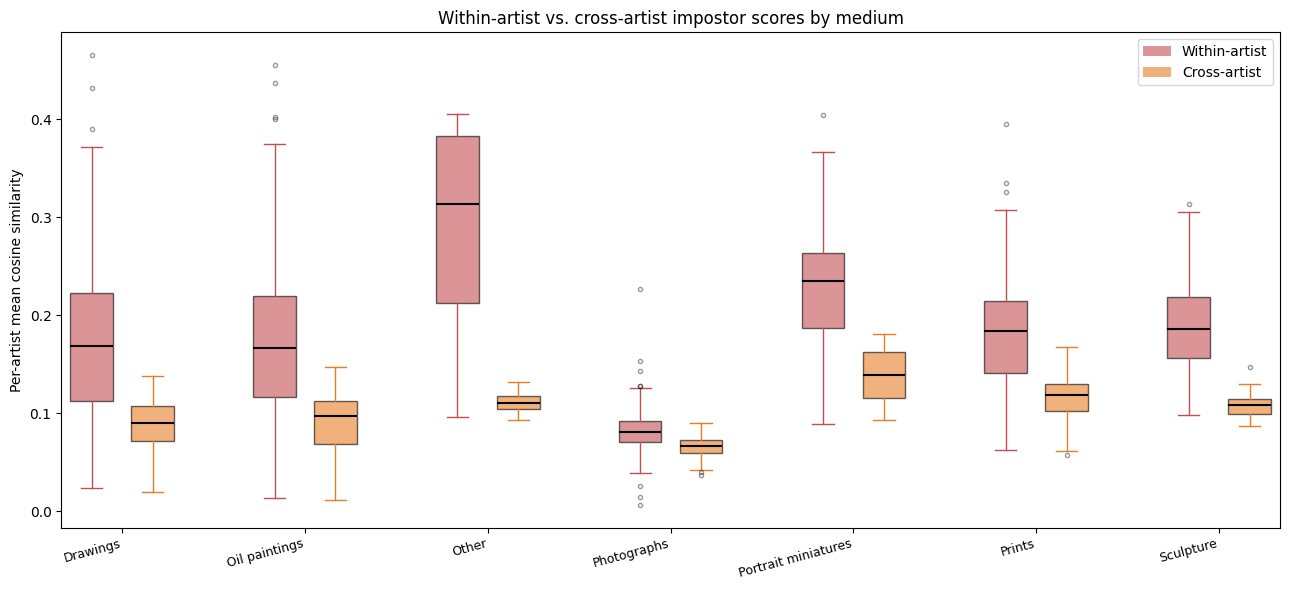

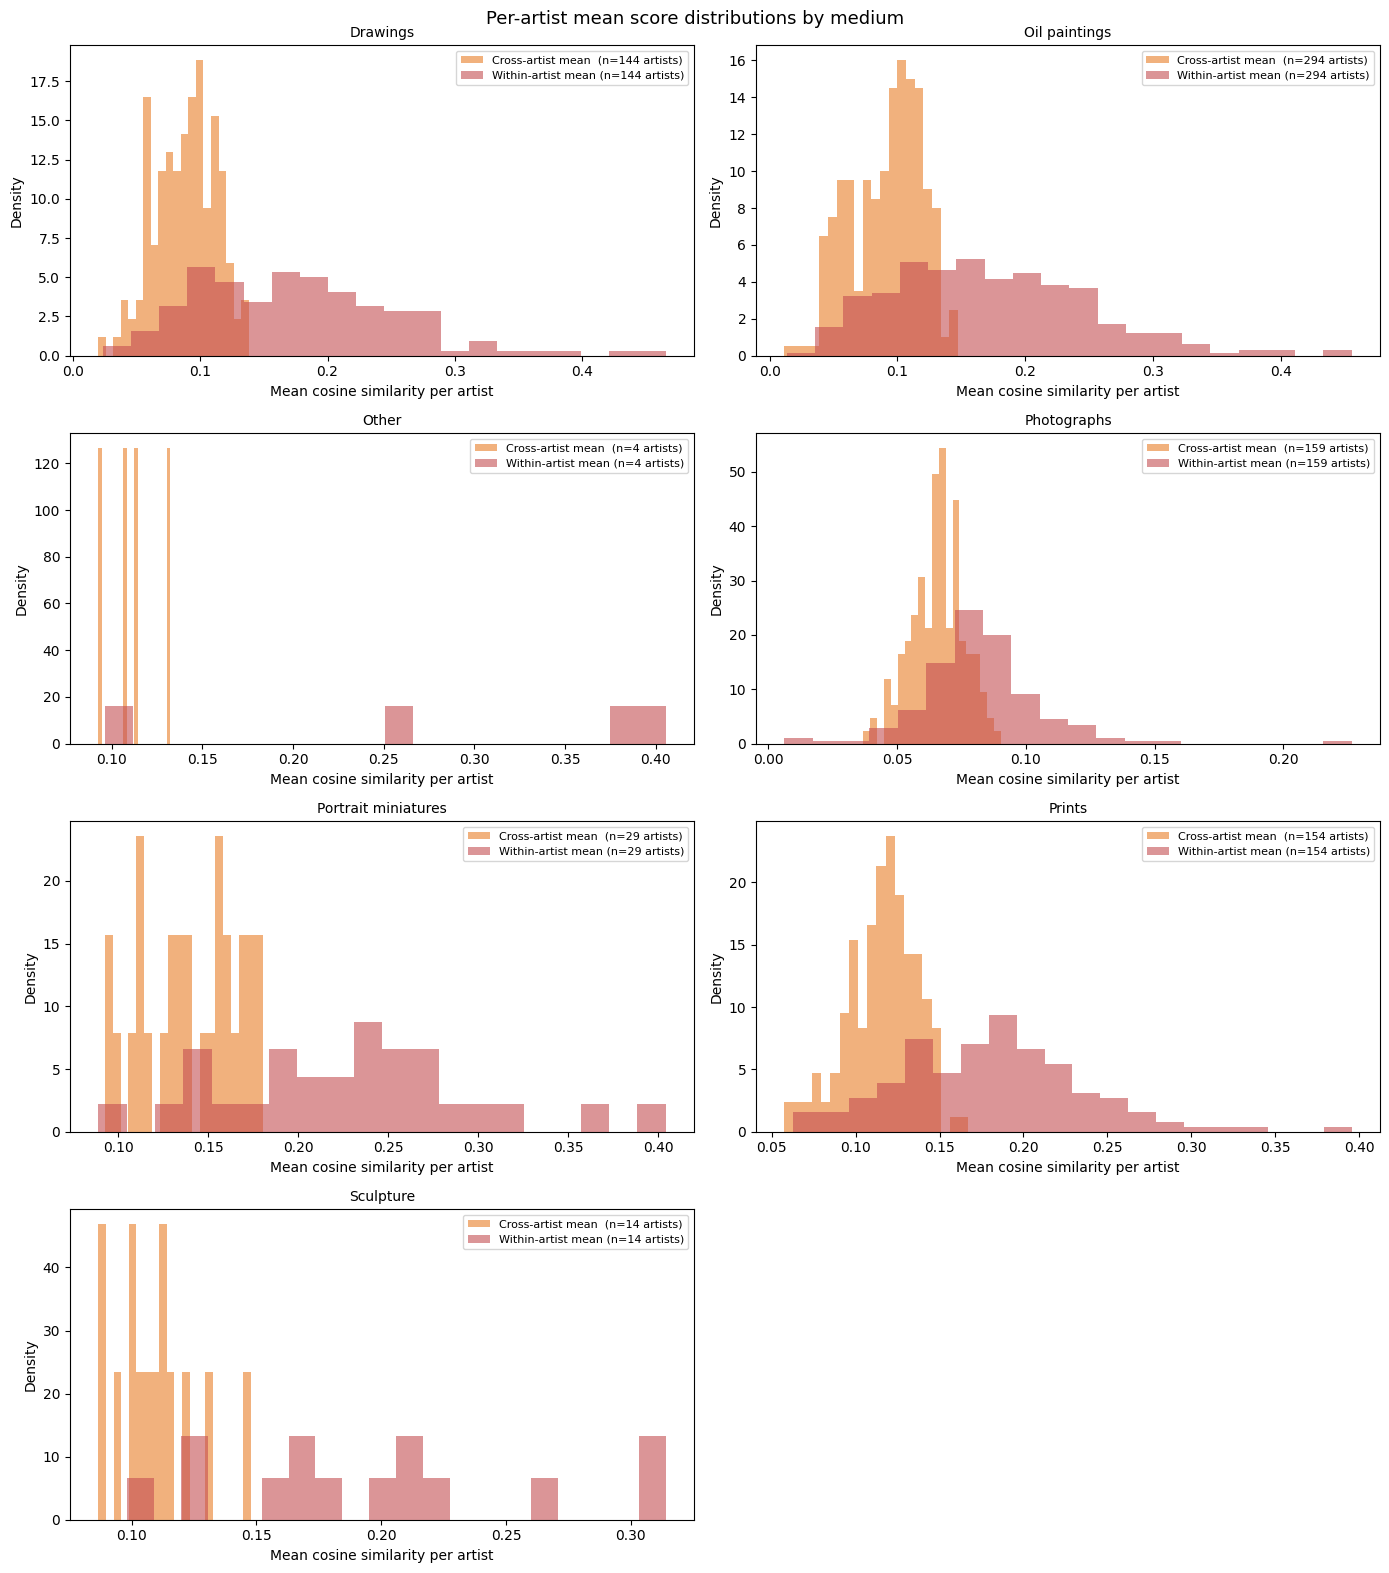

In [96]:
MIN_PAIRS_MED    = 3    # min within-artist pairs in a medium to include an artist
CROSS_SAMPLE_MED = 200  # cross-artist pairs sampled per (artist, medium)

# lref → medium_group lookup
lref_to_medium = df.set_index(df['lref'].astype(str))['medium_group'].to_dict()

# Tag within-artist pairs by medium (reuse within_pairs from EXP5a)
def tag_same_medium(pairs, lref_to_medium):
    tagged = []
    for row in pairs:
        med_a = lref_to_medium.get(str(row[0]))
        med_b = lref_to_medium.get(str(row[1]))
        if med_a is not None and med_a == med_b:
            tagged.append(row + (med_a,))
    return tagged

within_tagged = tag_same_medium(within_pairs, lref_to_medium)

# Build medium-stratified cross-artist pairs:
# for each (artist, medium), sample from portraits of OTHER artists in the SAME medium
medium_pool = {}  # medium → {lrefs, sitters, artists}
for _, row in df5.iterrows():
    med = lref_to_medium.get(str(int(row['lref'])))
    if med is None:
        continue
    if med not in medium_pool:
        medium_pool[med] = {'lrefs': [], 'sitters': [], 'artists': []}
    medium_pool[med]['lrefs'].append(str(int(row['lref'])))
    medium_pool[med]['sitters'].append(str(int(row['sitter_id'])))
    medium_pool[med]['artists'].append(int(row['artist_id']))

rng_5b = np.random.default_rng(42)
cross_tagged_med = []  # (lref_a, lref_b, artist_id, sitter_a, sitter_b, medium)

for medium, pool in medium_pool.items():
    pool_lrefs   = np.array(pool['lrefs'])
    pool_sitters = np.array(pool['sitters'])
    pool_artists = np.array(pool['artists'])
    artists_in_med = set(pool_artists) & qualifying

    for aid in artists_in_med:
        my_mask       = pool_artists == aid
        my_lrefs      = pool_lrefs[my_mask]
        my_sitters    = pool_sitters[my_mask]
        other_mask    = pool_artists != aid
        other_lrefs   = pool_lrefs[other_mask]
        other_sitters = pool_sitters[other_mask]
        if len(other_lrefs) == 0:
            continue

        collected, attempts = 0, 0
        while collected < CROSS_SAMPLE_MED and attempts < CROSS_SAMPLE_MED * 20:
            ia = rng_5b.integers(0, len(my_lrefs))
            ib = rng_5b.integers(0, len(other_lrefs))
            if my_sitters[ia] != other_sitters[ib]:
                cross_tagged_med.append((
                    my_lrefs[ia], other_lrefs[ib], aid,
                    my_sitters[ia], other_sitters[ib], medium
                ))
                collected += 1
            attempts += 1

print(f"Within-artist same-medium pairs: {len(within_tagged):,}")
print(f"Cross-artist same-medium pairs:  {len(cross_tagged_med):,}")

# Score both sets
def score_tagged_pairs(tagged, embeddings):
    scores, artists, mediums = [], [], []
    for row in tagged:
        ea = embeddings.get(str(row[0]))
        eb = embeddings.get(str(row[1]))
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
        artists.append(row[2])
        mediums.append(row[-1])
    return (np.array(scores, dtype=np.float32),
            np.array(artists),
            np.array(mediums, dtype=object))

wt_scores, wt_artists, wt_mediums = score_tagged_pairs(within_tagged,    emb_pretrained)
ct_scores, ct_artists, ct_mediums = score_tagged_pairs(cross_tagged_med, emb_pretrained)

all_media_5b = sorted(set(wt_mediums))

# Per-medium analysis
summary_rows = []
medium_data  = {}

for medium in all_media_5b:
    wm_mask = wt_mediums == medium
    cm_mask = ct_mediums == medium

    w_scores_med  = wt_scores[wm_mask]
    w_artists_med = wt_artists[wm_mask]
    c_scores_med  = ct_scores[cm_mask]
    c_artists_med = ct_artists[cm_mask]

    w_means, c_means = [], []
    for aid in np.unique(w_artists_med):
        w_mask = w_artists_med == aid
        c_mask = c_artists_med == aid
        if w_mask.sum() < MIN_PAIRS_MED or c_mask.sum() == 0:
            continue
        w_means.append(float(np.mean(w_scores_med[w_mask])))
        c_means.append(float(np.mean(c_scores_med[c_mask])))

    if len(w_means) < 2:
        continue

    wm     = np.array(w_means)
    cm_arr = np.array(c_means)
    deltas = wm - cm_arr
    stat, p = mannwhitneyu(wm, cm_arr, alternative='greater')

    summary_rows.append({
        'Medium':      medium,
        'N artists':   len(wm),
        'Mean within': round(float(np.mean(wm)), 4),
        'Std within':  round(float(np.std(wm)), 4),
        'Mean cross':  round(float(np.mean(cm_arr)), 4),
        'Std cross':   round(float(np.std(cm_arr)), 4),
        'Mean delta':  round(float(np.mean(deltas)), 4),
        'p-value':     round(p, 4),
    })
    medium_data[medium] = {'wm': wm, 'cm': cm_arr}

display(pd.DataFrame(summary_rows).style.format({
    'Mean within': '{:.4f}', 'Std within': '{:.4f}',
    'Mean cross':  '{:.4f}', 'Std cross':  '{:.4f}',
    'Mean delta':  '{:+.4f}', 'p-value':   '{:.4f}',
    'N artists':   '{:,}',
}))

# Plot 1: grouped boxplot: within vs cross per-artist means, side by side per medium
from matplotlib.patches import Patch

media_list = list(medium_data.keys())
positions_w, positions_c = [], []
box_w, box_c = [], []
for i, medium in enumerate(media_list):
    positions_w.append(i * 3 + 0.75)
    positions_c.append(i * 3 + 1.75)
    box_w.append(medium_data[medium]['wm'])
    box_c.append(medium_data[medium]['cm'])

fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(box_w, positions=positions_w, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#C44E52', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#C44E52'), capprops=dict(color='#C44E52'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#C44E52'))
ax.boxplot(box_c, positions=positions_c, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#E87D27', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#E87D27'), capprops=dict(color='#E87D27'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E87D27'))
ax.set_xticks([i * 3 + 1.25 for i in range(len(media_list))])
ax.set_xticklabels(media_list, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Per-artist mean cosine similarity')
ax.set_title('Within-artist vs. cross-artist impostor scores by medium')
ax.legend([Patch(facecolor='#C44E52', alpha=0.6), Patch(facecolor='#E87D27', alpha=0.6)],
          ['Within-artist', 'Cross-artist'], fontsize=10)
plt.tight_layout()
plt.show()

# Plot 2: per-medium histograms of per-artist mean scores
ncols = 2
nrows = (len(medium_data) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, medium in enumerate(media_list):
    ax = axes[i]
    d  = medium_data[medium]
    ax.hist(d['cm'], bins=20, density=True, alpha=0.6, color='#E87D27',
            label=f'Cross-artist mean  (n={len(d["cm"])} artists)')
    ax.hist(d['wm'], bins=20, density=True, alpha=0.6, color='#C44E52',
            label=f'Within-artist mean (n={len(d["wm"])} artists)')
    ax.set_title(medium, fontsize=10)
    ax.set_xlabel('Mean cosine similarity per artist')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Per-artist mean score distributions by medium', fontsize=13)
plt.tight_layout()
plt.show()

---
## EXP6: Difficulty of genuine pairs (pretrained model)

**RQ1-C:** Are within-artist genuine pairs easier to verify than cross-artist genuine pairs, suggesting the model exploits shared painterly style rather than identity alone?

- **Within-artist genuine**: same sitter, same artist — model sees same style + same identity
- **Cross-artist genuine**: same sitter, different artists — model sees different style, only identity signal

Both conditions are evaluated against the **same shared impostor pool** (cross-artist impostors from EXP5a), so any AUC/EER difference isolates the effect of genuine pair type.

Within-artist genuine pairs: 28,595
Cross-artist genuine pairs:  139,951
Shared impostor pairs:       131,600


,Condition,N genuine,N impostor,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Within-artist genuine,"28,595","131,600",0.9677,0.9809,0.0938,0.7558,0.5924
1,Cross-artist genuine,"139,951","131,600",0.9316,0.9428,0.1446,0.5602,0.3450



Mann-Whitney U (within genuine > cross genuine): U=2687248640.0,  p=0.0000
--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)


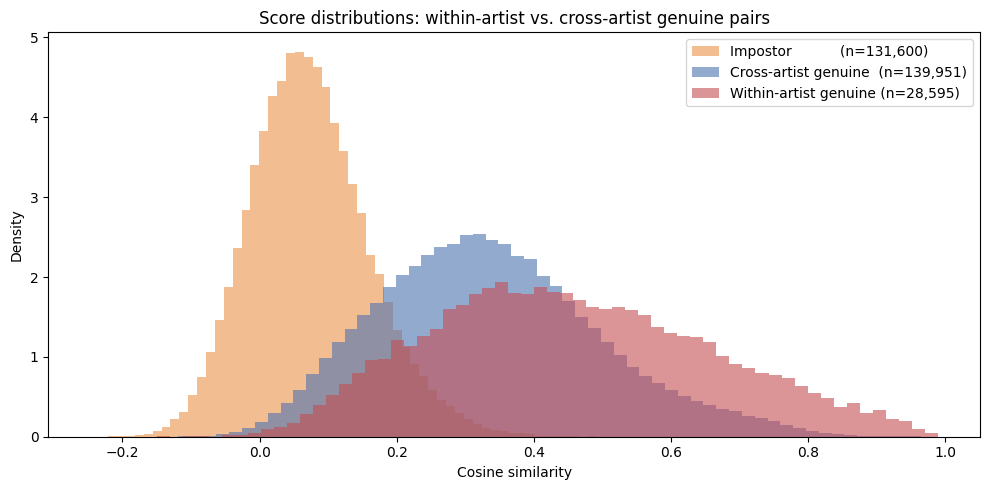

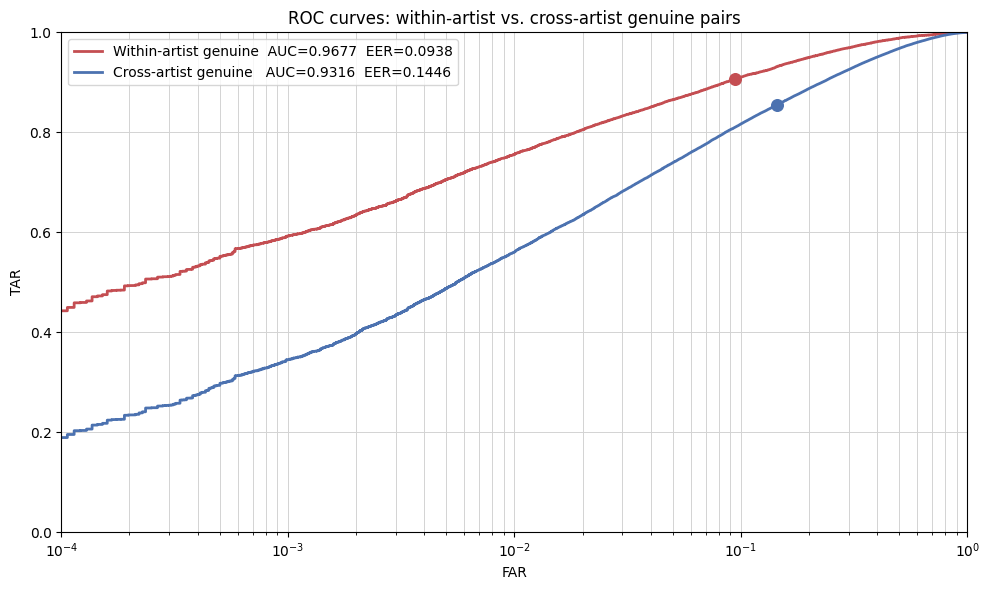

In [97]:
# Step 1: within-artist genuine pairs (full df, all artists with known artist_id)
df6 = df.dropna(subset=['artist_id']).copy()
df6['artist_id']  = df6['artist_id'].astype(int)
df6['sitter_id']  = df6['sitter_id'].astype(int)

within_genuine = []
for (artist_id, sitter_id), grp in df6.groupby(['artist_id', 'sitter_id']):
    lrefs = grp['lref'].astype(str).tolist()
    if len(lrefs) < 2:
        continue
    sid = str(sitter_id)
    for la, lb in itr_combinations(lrefs, 2):
        within_genuine.append((la, lb, 1, sid, sid))

# Step 2: cross-artist genuine pairs (sitters appearing in ≥2 different artists' work)
cross_genuine = []
for sitter_id, grp in df6.groupby('sitter_id'):
    if grp['artist_id'].nunique() < 2:
        continue
    portraits = list(zip(grp['lref'].astype(str).tolist(),
                         grp['artist_id'].tolist()))
    sid = str(sitter_id)
    for (la, aid_a), (lb, aid_b) in itr_combinations(portraits, 2):
        if aid_a != aid_b:
            cross_genuine.append((la, lb, 1, sid, sid))

# Step 3: shared impostor pool from EXP5a's cross_pairs
# cross_pairs format: (lref_a, lref_b, artist_id, sitter_a, sitter_b)
impostor_pairs_6 = [(la, lb, 0, sa, sb) for la, lb, _, sa, sb in cross_pairs]

print(f"Within-artist genuine pairs: {len(within_genuine):,}")
print(f"Cross-artist genuine pairs:  {len(cross_genuine):,}")
print(f"Shared impostor pairs:       {len(impostor_pairs_6):,}")

# Step 4: score each condition against the same impostor pool
sc_w, lb_w, sa_w, sb_w = score_pairs(within_genuine + impostor_pairs_6, emb_pretrained)
sc_c, lb_c, sa_c, sb_c = score_pairs(cross_genuine  + impostor_pairs_6, emb_pretrained)

# Step 5: compute metrics
m_w = compute_metrics(sc_w, lb_w, sa_w, sb_w)
m_c = compute_metrics(sc_c, lb_c, sa_c, sb_c)

# Summary table
display(pd.DataFrame([
    {'Condition':  'Within-artist genuine',
     'N genuine':  int(lb_w.sum()), 'N impostor': int((lb_w == 0).sum()),
     'AUC':        m_w['AUC'],  'Macro-AUC': m_w['macro_AUC'],
     'EER':        m_w['EER'],  'TAR@1%':    m_w['TAR@1%'], 'TAR@0.1%': m_w['TAR@0.1%']},
    {'Condition':  'Cross-artist genuine',
     'N genuine':  int(lb_c.sum()), 'N impostor': int((lb_c == 0).sum()),
     'AUC':        m_c['AUC'],  'Macro-AUC': m_c['macro_AUC'],
     'EER':        m_c['EER'],  'TAR@1%':    m_c['TAR@1%'], 'TAR@0.1%': m_c['TAR@0.1%']},
]).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'N genuine': '{:,}', 'N impostor': '{:,}',
}))

# Mann-Whitney U: within-genuine scores > cross-genuine scores
gen_w_scores = sc_w[lb_w == 1]
gen_c_scores = sc_c[lb_c == 1]
stat6, p6 = mannwhitneyu(gen_w_scores, gen_c_scores, alternative='greater')
print(f"\nMann-Whitney U (within genuine > cross genuine): U={stat6:.1f},  p={p6:.4f}")
if p6 < 0.05:
    print("--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)")
else:
    print("--> No significant difference")

# Plot 1: 3-way score distribution
imp_scores = sc_w[lb_w == 0]  # same impostor pool for both conditions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(imp_scores,   bins=60, density=True, alpha=0.5, color='#E87D27',
        label=f'Impostor           (n={len(imp_scores):,})')
ax.hist(gen_c_scores, bins=60, density=True, alpha=0.6, color='#4C72B0',
        label=f'Cross-artist genuine  (n={len(gen_c_scores):,})')
ax.hist(gen_w_scores, bins=60, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist genuine (n={len(gen_w_scores):,})')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Score distributions: within-artist vs. cross-artist genuine pairs')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: ROC curve comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(m_w['_fpr'], m_w['_tpr'], color='#C44E52', lw=2,
        label=f"Within-artist genuine  AUC={m_w['AUC']:.4f}  EER={m_w['EER']:.4f}")
ax.scatter([m_w['EER']], [1 - m_w['EER']], color='#C44E52', s=70, zorder=5)
ax.plot(m_c['_fpr'], m_c['_tpr'], color='#4C72B0', lw=2,
        label=f"Cross-artist genuine   AUC={m_c['AUC']:.4f}  EER={m_c['EER']:.4f}")
ax.scatter([m_c['EER']], [1 - m_c['EER']], color='#4C72B0', s=70, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: within-artist vs. cross-artist genuine pairs')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
### EXP7: Does fine-tuning help or hurt artist bias?

Repeats the EXP5/EXP6 artist-bias analyses using the **EXP3 fine-tuned** model (IResNet100 fine-tuned on RKD, all media) instead of the pretrained backbone. Fine-tuning on RKD portrait data could plausibly *increase* artist bias (the model sees more examples of each artist's distinctive style during training) or *decrease* it (more identity-specific training signal crowds out the style shortcut). This tests which.

- **EXP7a** (↔ EXP5a): within-artist vs. cross-artist impostor scores, fine-tuned model.
- **EXP7b** (↔ EXP5b): same analysis, stratified by medium.
- **EXP7c** (↔ EXP6): within-artist vs. cross-artist genuine-pair difficulty, fine-tuned model.

All three reuse the pair sets built in EXP5a (cell-20), EXP5b (cell-22), and EXP6 (cell-24); only the scoring model changes.

,Group,N artists,Mean,Median,Std
0,Within-artist impostors,658,0.0631,0.0561,0.0400
1,Cross-artist impostors,658,0.0022,0.0021,0.0049



Mann-Whitney U (within > cross): U=425619.0,  p=0.0000
--> Within-artist impostor scores are significantly higher (artist bias detected)


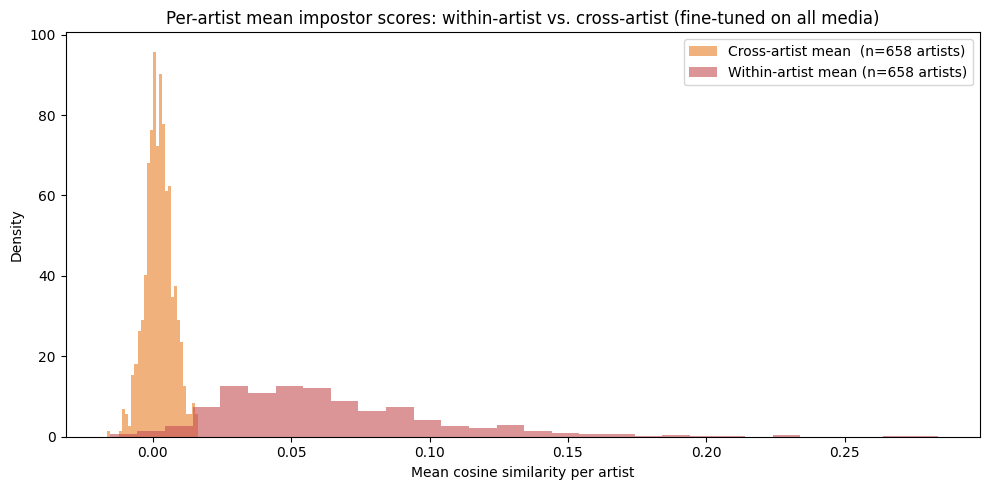

C:\Users\jenne\AppData\Local\Temp\ipykernel_40980\779989782.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data_7a, labels=box_labels_7a, vert=True)


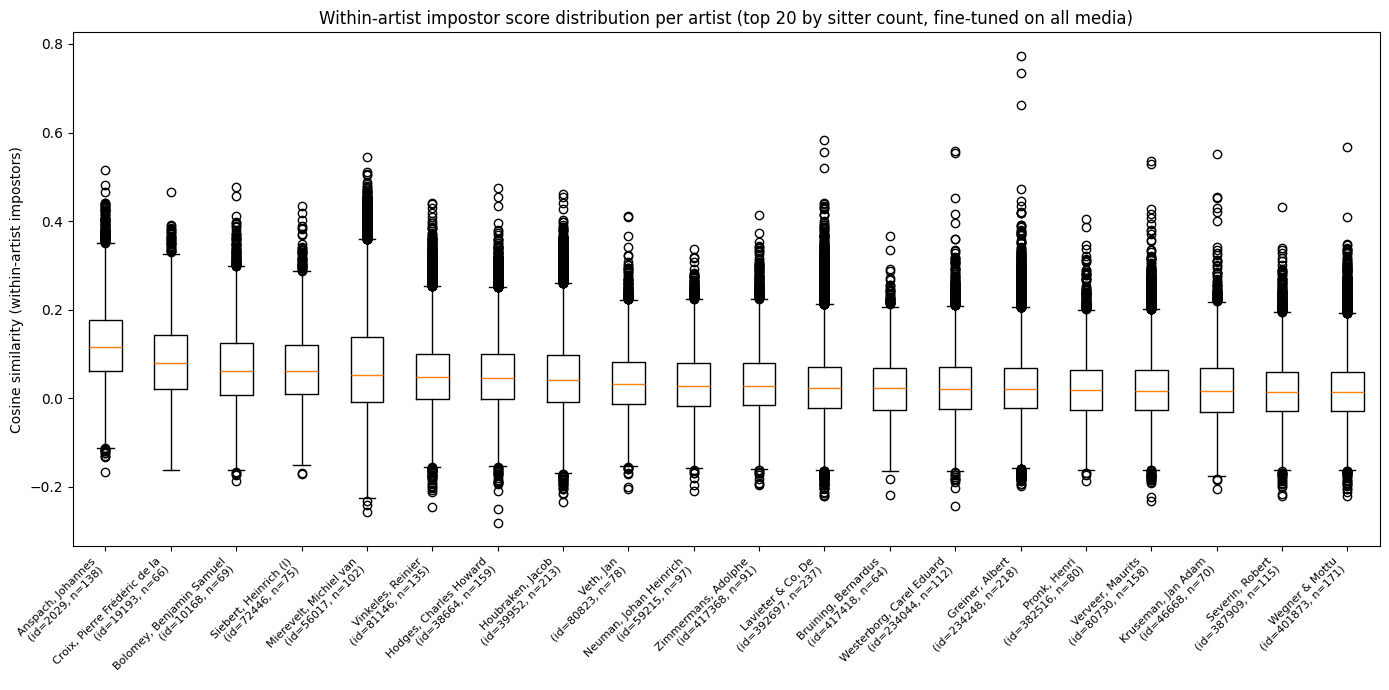

In [98]:
# EXP7a: replicate EXP5a (within-artist vs. cross-artist impostor scores) — EXP3 fine-tuned model
# Reuses within_pairs, cross_pairs, qualifying, artist_sitter_counts, df5, score_artist_pairs from EXP5a (cell-20).

within_scores_7a, within_artist_ids_7a = score_artist_pairs(within_pairs, emb_exp3)
cross_scores_7a,  cross_artist_ids_7a  = score_artist_pairs(cross_pairs,  emb_exp3)

within_means_7a = {aid: float(np.mean(within_scores_7a[within_artist_ids_7a == aid]))
                   for aid in qualifying if (within_artist_ids_7a == aid).sum() > 0}
cross_means_7a  = {aid: float(np.mean(cross_scores_7a[cross_artist_ids_7a == aid]))
                   for aid in qualifying if (cross_artist_ids_7a == aid).sum() > 0}

common_7a = set(within_means_7a) & set(cross_means_7a)
wm_7a = np.array([within_means_7a[a] for a in common_7a])
cm_7a = np.array([cross_means_7a[a]  for a in common_7a])

# Summary table
display(pd.DataFrame({
    'Group':        ['Within-artist impostors', 'Cross-artist impostors'],
    'N artists':    [len(within_means_7a), len(cross_means_7a)],
    'Mean':         [round(float(np.mean(wm_7a)), 4),   round(float(np.mean(cm_7a)), 4)],
    'Median':       [round(float(np.median(wm_7a)), 4), round(float(np.median(cm_7a)), 4)],
    'Std':          [round(float(np.std(wm_7a)), 4),    round(float(np.std(cm_7a)), 4)],
}))

stat7a, p7a = mannwhitneyu(wm_7a, cm_7a, alternative='greater')
print(f"\nMann-Whitney U (within > cross): U={stat7a:.1f},  p={p7a:.4f}")
if p7a < 0.05:
    print("--> Within-artist impostor scores are significantly higher (artist bias detected)")
else:
    print("--> No significant difference (no strong artist bias)")

# Plot: histogram of per-artist means
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cm_7a, bins=30, density=True, alpha=0.6, color='#E87D27',
        label=f'Cross-artist mean  (n={len(cm_7a)} artists)')
ax.hist(wm_7a, bins=30, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist mean (n={len(wm_7a)} artists)')
ax.set_xlabel('Mean cosine similarity per artist')
ax.set_ylabel('Density')
ax.set_title('Per-artist mean impostor scores: within-artist vs. cross-artist (fine-tuned on all media)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot: per-artist boxplot (top 20 by sitter count, sorted by median)
top20_ids_7a = (artist_sitter_counts[artist_sitter_counts.index.isin(qualifying)]
                .sort_values(ascending=False).head(20).index.tolist())
artist_id_to_name_7a = df5.drop_duplicates('artist_id').set_index('artist_id')['artist_name'].to_dict()

box_data_7a, box_labels_7a, box_medians_7a = [], [], []
for aid in top20_ids_7a:
    mask = within_artist_ids_7a == aid
    if mask.sum() == 0:
        continue
    d    = within_scores_7a[mask]
    name = artist_id_to_name_7a.get(aid, str(aid))
    box_data_7a.append(d)
    box_labels_7a.append(f"{name[:28]}\n(id={aid}, n={artist_sitter_counts[aid]})")
    box_medians_7a.append(float(np.median(d)))

order_7a      = np.argsort(box_medians_7a)[::-1]
box_data_7a   = [box_data_7a[i]   for i in order_7a]
box_labels_7a = [box_labels_7a[i] for i in order_7a]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data_7a, labels=box_labels_7a, vert=True)
ax.set_ylabel('Cosine similarity (within-artist impostors)')
ax.set_title('Within-artist impostor score distribution per artist (top 20 by sitter count, fine-tuned on all media)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

,Medium,N artists,Mean within,Std within,Mean cross,Std cross,Mean delta,p-value
0,Drawings,144,0.0816,0.0457,0.0088,0.0054,+0.0728,0.0000
1,Oil paintings,294,0.0736,0.0434,0.0054,0.0060,+0.0682,0.0000
2,Other,4,0.1965,0.0674,0.0255,0.0176,+0.1710,0.0143
3,Photographs,159,0.0338,0.0218,0.0160,0.0060,+0.0178,0.0000
4,Portrait miniatures,29,0.0854,0.0433,0.0170,0.0109,+0.0684,0.0000
5,Prints,154,0.0769,0.0447,0.0218,0.0098,+0.0551,0.0000
6,Sculpture,14,0.0937,0.0353,0.0324,0.0119,+0.0613,0.0000


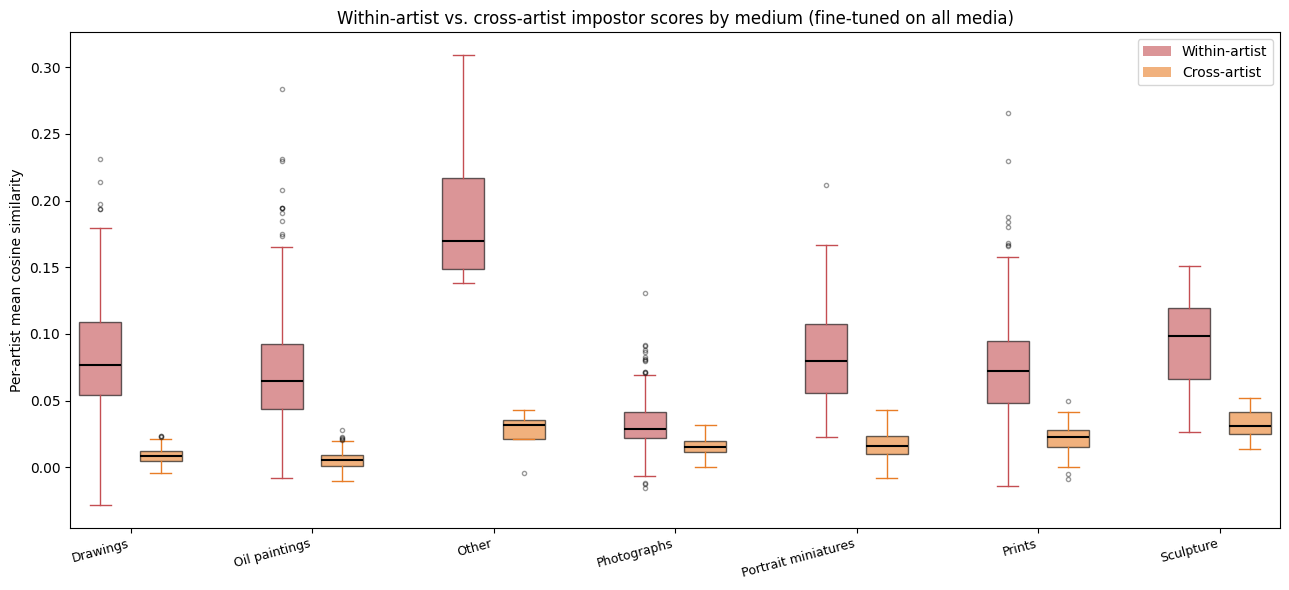

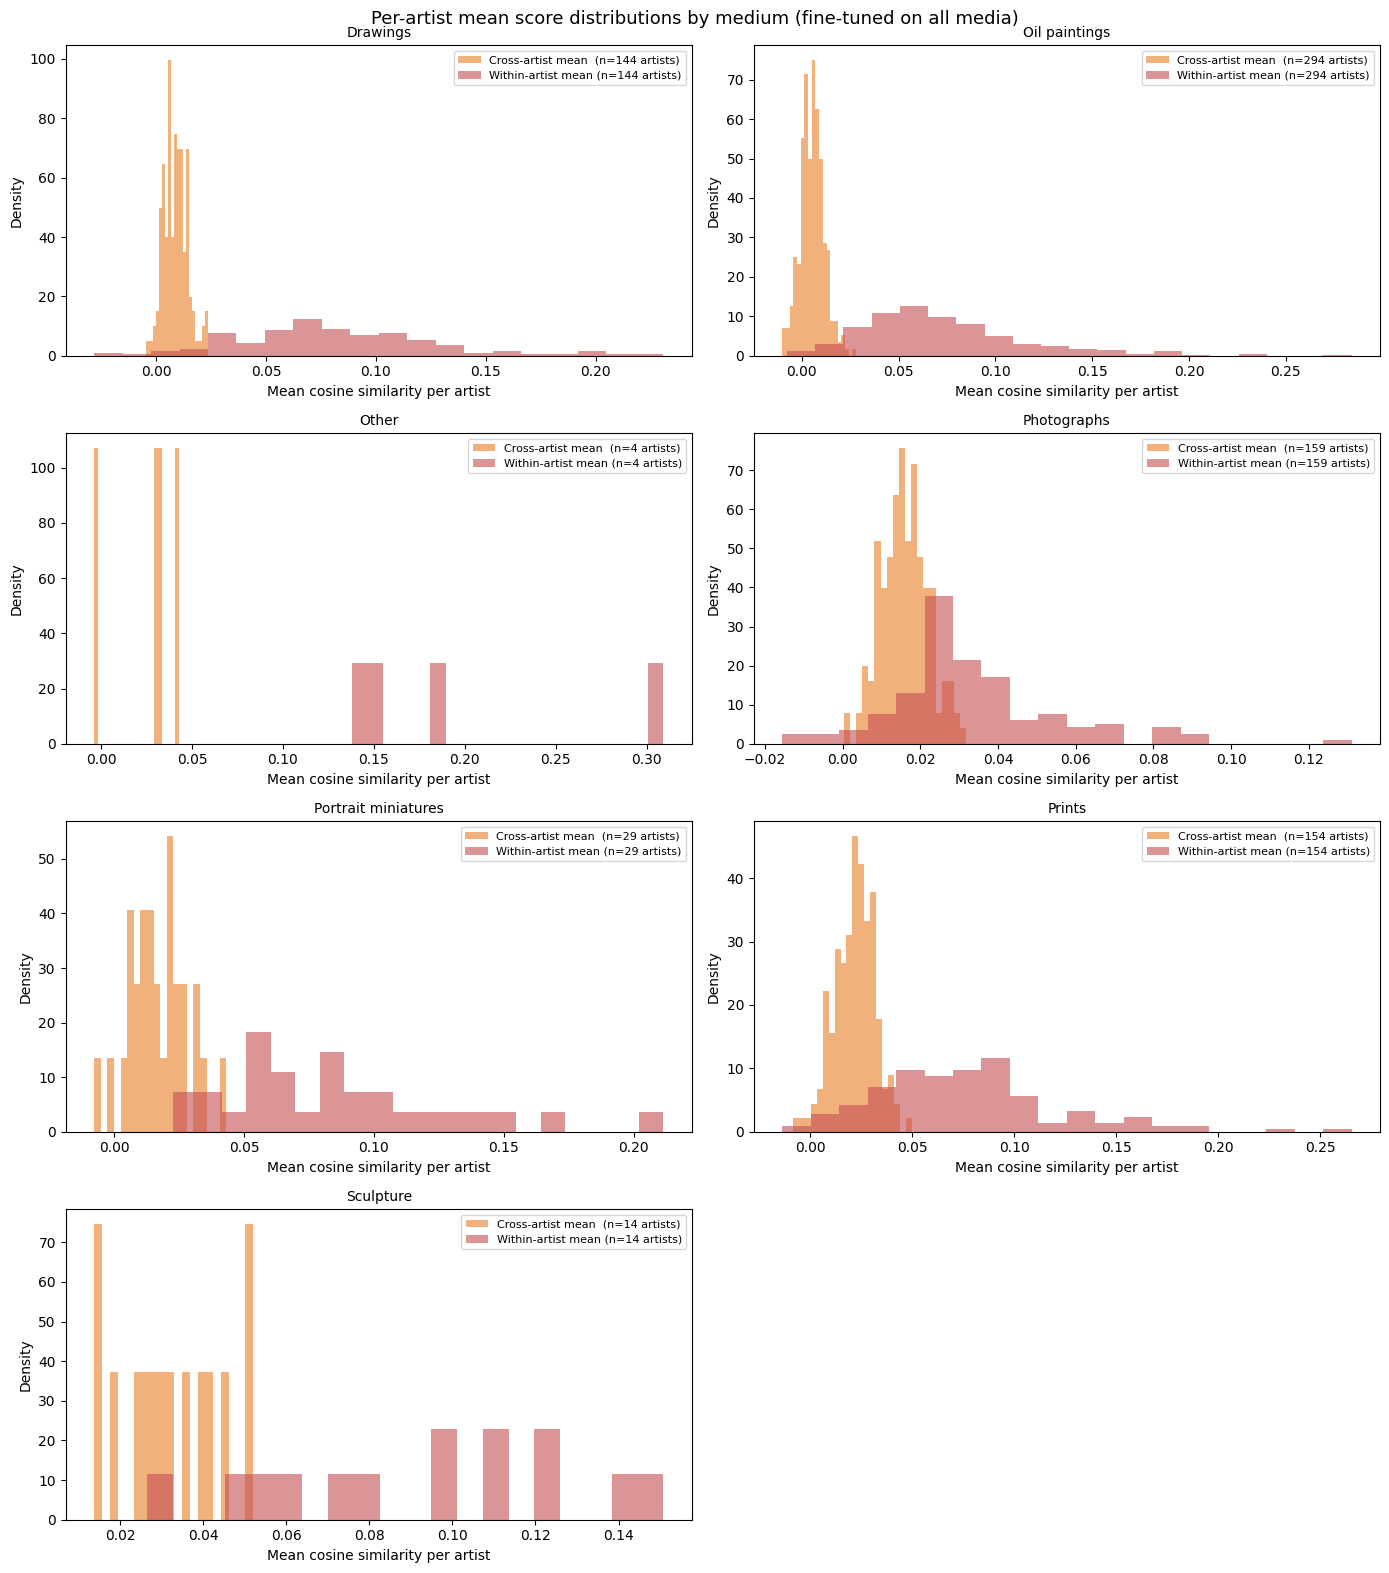

In [99]:
# EXP7b: replicate EXP5b (within-artist vs. cross-artist impostor scores, by medium) — EXP3 fine-tuned model
# Reuses within_tagged, cross_tagged_med, score_tagged_pairs, MIN_PAIRS_MED from EXP5b (cell-22).

wt_scores_7b, wt_artists_7b, wt_mediums_7b = score_tagged_pairs(within_tagged,    emb_exp3)
ct_scores_7b, ct_artists_7b, ct_mediums_7b = score_tagged_pairs(cross_tagged_med, emb_exp3)

all_media_7b = sorted(set(wt_mediums_7b))

# Per-medium analysis
summary_rows_7b = []
medium_data_7b  = {}

for medium in all_media_7b:
    wm_mask = wt_mediums_7b == medium
    cm_mask = ct_mediums_7b == medium

    w_scores_med  = wt_scores_7b[wm_mask]
    w_artists_med = wt_artists_7b[wm_mask]
    c_scores_med  = ct_scores_7b[cm_mask]
    c_artists_med = ct_artists_7b[cm_mask]

    w_means, c_means = [], []
    for aid in np.unique(w_artists_med):
        w_mask = w_artists_med == aid
        c_mask = c_artists_med == aid
        if w_mask.sum() < MIN_PAIRS_MED or c_mask.sum() == 0:
            continue
        w_means.append(float(np.mean(w_scores_med[w_mask])))
        c_means.append(float(np.mean(c_scores_med[c_mask])))

    if len(w_means) < 2:
        continue

    wm     = np.array(w_means)
    cm_arr = np.array(c_means)
    deltas = wm - cm_arr
    stat, p = mannwhitneyu(wm, cm_arr, alternative='greater')

    summary_rows_7b.append({
        'Medium':      medium,
        'N artists':   len(wm),
        'Mean within': round(float(np.mean(wm)), 4),
        'Std within':  round(float(np.std(wm)), 4),
        'Mean cross':  round(float(np.mean(cm_arr)), 4),
        'Std cross':   round(float(np.std(cm_arr)), 4),
        'Mean delta':  round(float(np.mean(deltas)), 4),
        'p-value':     round(p, 4),
    })
    medium_data_7b[medium] = {'wm': wm, 'cm': cm_arr}

display(pd.DataFrame(summary_rows_7b).style.format({
    'Mean within': '{:.4f}', 'Std within': '{:.4f}',
    'Mean cross':  '{:.4f}', 'Std cross':  '{:.4f}',
    'Mean delta':  '{:+.4f}', 'p-value':   '{:.4f}',
    'N artists':   '{:,}',
}))

# Plot 1: grouped boxplot: within vs cross per-artist means, side by side per medium
from matplotlib.patches import Patch

media_list_7b = list(medium_data_7b.keys())
positions_w_7b, positions_c_7b = [], []
box_w_7b, box_c_7b = [], []
for i, medium in enumerate(media_list_7b):
    positions_w_7b.append(i * 3 + 0.75)
    positions_c_7b.append(i * 3 + 1.75)
    box_w_7b.append(medium_data_7b[medium]['wm'])
    box_c_7b.append(medium_data_7b[medium]['cm'])

fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(box_w_7b, positions=positions_w_7b, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#C44E52', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#C44E52'), capprops=dict(color='#C44E52'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#C44E52'))
ax.boxplot(box_c_7b, positions=positions_c_7b, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#E87D27', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#E87D27'), capprops=dict(color='#E87D27'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E87D27'))
ax.set_xticks([i * 3 + 1.25 for i in range(len(media_list_7b))])
ax.set_xticklabels(media_list_7b, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Per-artist mean cosine similarity')
ax.set_title('Within-artist vs. cross-artist impostor scores by medium (fine-tuned on all media)')
ax.legend([Patch(facecolor='#C44E52', alpha=0.6), Patch(facecolor='#E87D27', alpha=0.6)],
          ['Within-artist', 'Cross-artist'], fontsize=10)
plt.tight_layout()
plt.show()

# Plot 2: per-medium histograms of per-artist mean scores
ncols = 2
nrows = (len(medium_data_7b) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, medium in enumerate(media_list_7b):
    ax = axes[i]
    d  = medium_data_7b[medium]
    ax.hist(d['cm'], bins=20, density=True, alpha=0.6, color='#E87D27',
            label=f'Cross-artist mean  (n={len(d["cm"])} artists)')
    ax.hist(d['wm'], bins=20, density=True, alpha=0.6, color='#C44E52',
            label=f'Within-artist mean (n={len(d["wm"])} artists)')
    ax.set_title(medium, fontsize=10)
    ax.set_xlabel('Mean cosine similarity per artist')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Per-artist mean score distributions by medium (fine-tuned on all media)', fontsize=13)
plt.tight_layout()
plt.show()

,Condition,N genuine,N impostor,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Within-artist genuine,"28,595","131,600",0.9950,0.9957,0.0266,0.9599,0.9235
1,Cross-artist genuine,"139,951","131,600",0.9955,0.9874,0.0223,0.9719,0.9490



Mann-Whitney U (within genuine > cross genuine): U=2430127360.0,  p=0.0000
--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)


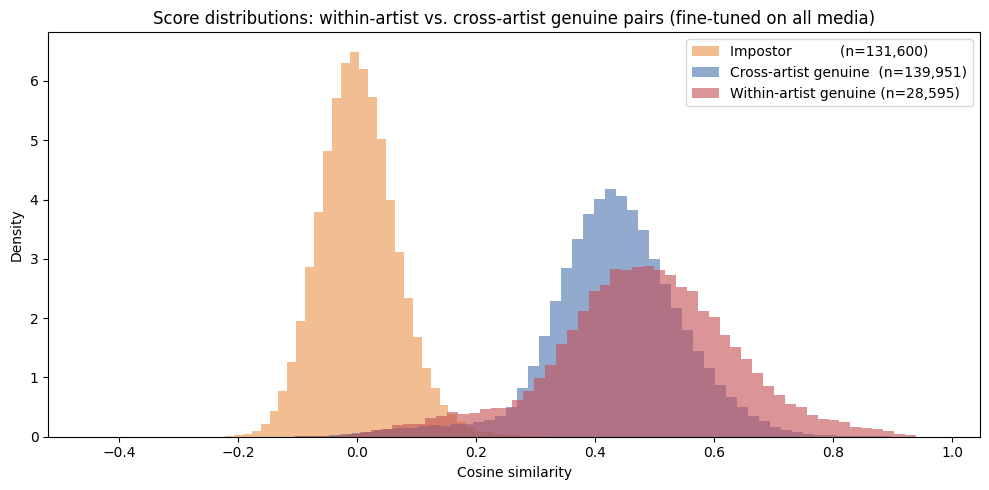

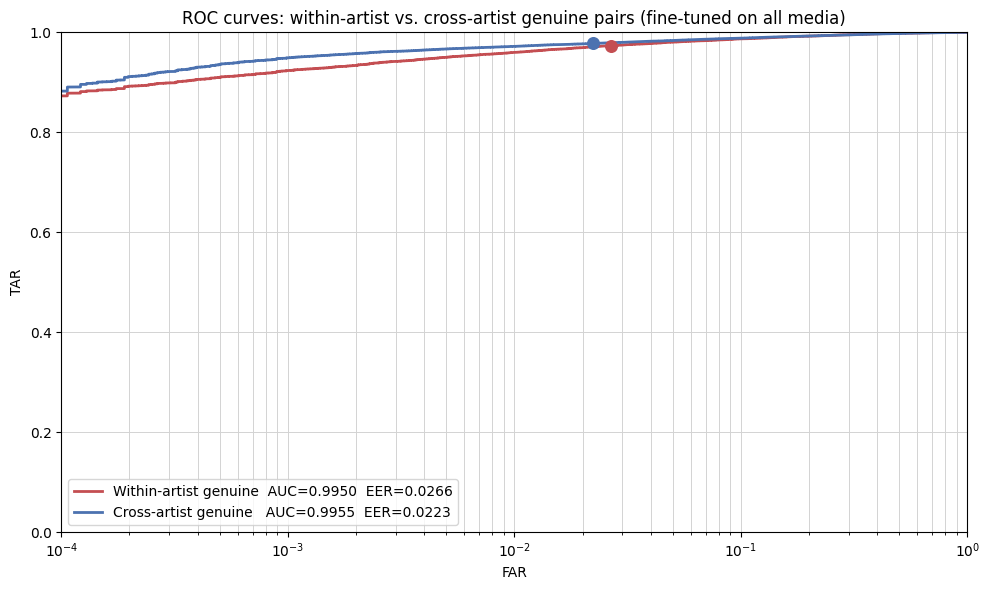

In [100]:
# EXP7c: replicate EXP6 (within-artist vs. cross-artist genuine pairs) — EXP3 fine-tuned model
# Reuses within_genuine, cross_genuine, impostor_pairs_6 from EXP6 (cell-24).

sc_w7c, lb_w7c, sa_w7c, sb_w7c = score_pairs(within_genuine + impostor_pairs_6, emb_exp3)
sc_c7c, lb_c7c, sa_c7c, sb_c7c = score_pairs(cross_genuine  + impostor_pairs_6, emb_exp3)

m_w7c = compute_metrics(sc_w7c, lb_w7c, sa_w7c, sb_w7c)
m_c7c = compute_metrics(sc_c7c, lb_c7c, sa_c7c, sb_c7c)

# Summary table
display(pd.DataFrame([
    {'Condition':  'Within-artist genuine',
     'N genuine':  int(lb_w7c.sum()), 'N impostor': int((lb_w7c == 0).sum()),
     'AUC':        m_w7c['AUC'],  'Macro-AUC': m_w7c['macro_AUC'],
     'EER':        m_w7c['EER'],  'TAR@1%':    m_w7c['TAR@1%'], 'TAR@0.1%': m_w7c['TAR@0.1%']},
    {'Condition':  'Cross-artist genuine',
     'N genuine':  int(lb_c7c.sum()), 'N impostor': int((lb_c7c == 0).sum()),
     'AUC':        m_c7c['AUC'],  'Macro-AUC': m_c7c['macro_AUC'],
     'EER':        m_c7c['EER'],  'TAR@1%':    m_c7c['TAR@1%'], 'TAR@0.1%': m_c7c['TAR@0.1%']},
]).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'N genuine': '{:,}', 'N impostor': '{:,}',
}))

# Mann-Whitney U: within-genuine scores > cross-genuine scores
gen_w7c = sc_w7c[lb_w7c == 1]
gen_c7c = sc_c7c[lb_c7c == 1]
stat7c, p7c = mannwhitneyu(gen_w7c, gen_c7c, alternative='greater')
print(f"\nMann-Whitney U (within genuine > cross genuine): U={stat7c:.1f},  p={p7c:.4f}")
if p7c < 0.05:
    print("--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)")
else:
    print("--> No significant difference")

# Plot 1: 3-way score distribution
imp_scores7c = sc_w7c[lb_w7c == 0]  # same impostor pool for both conditions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(imp_scores7c, bins=60, density=True, alpha=0.5, color='#E87D27',
        label=f'Impostor           (n={len(imp_scores7c):,})')
ax.hist(gen_c7c, bins=60, density=True, alpha=0.6, color='#4C72B0',
        label=f'Cross-artist genuine  (n={len(gen_c7c):,})')
ax.hist(gen_w7c, bins=60, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist genuine (n={len(gen_w7c):,})')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Score distributions: within-artist vs. cross-artist genuine pairs (fine-tuned on all media)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: ROC curve comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(m_w7c['_fpr'], m_w7c['_tpr'], color='#C44E52', lw=2,
        label=f"Within-artist genuine  AUC={m_w7c['AUC']:.4f}  EER={m_w7c['EER']:.4f}")
ax.scatter([m_w7c['EER']], [1 - m_w7c['EER']], color='#C44E52', s=70, zorder=5)
ax.plot(m_c7c['_fpr'], m_c7c['_tpr'], color='#4C72B0', lw=2,
        label=f"Cross-artist genuine   AUC={m_c7c['AUC']:.4f}  EER={m_c7c['EER']:.4f}")
ax.scatter([m_c7c['EER']], [1 - m_c7c['EER']], color='#4C72B0', s=70, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: within-artist vs. cross-artist genuine pairs (fine-tuned on all media)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Per-sitter difficulty analysis

Which sitters are hardest to verify, and why? For each sitter with ≥4 portraits we compute a **cohesion score** — the mean pairwise cosine similarity across all their portraits. A low cohesion score means the model assigns low similarity to the same person's portraits: a hard sitter.

We then correlate cohesion with portrait count, medium diversity, artist diversity, and date span to understand what drives difficulty. The similarity matrix visualises the block structure across the hardest sitters.

Sitters with ≥4 portraits: 1,749
Portraits in filtered set: 13,282



Sitters with cohesion score: 1,749
Cohesion  mean=0.4410  median=0.4315  std=0.1451

--- Hardest 15 sitters (lowest cohesion) ---


,sitter_id,cohesion,n_portraits,n_media,n_artists,year_span
0,127480,0.0710,4,1,3,38
1,131445,0.0829,4,1,3,60
2,116093,0.0921,4,4,2,99
3,107237,0.0948,4,1,2,49
4,120095,0.0994,4,4,2,54
5,116336,0.1137,4,4,3,60
6,116252,0.1186,4,2,3,40
7,100157,0.1201,6,2,2,24
8,108917,0.1214,6,3,5,64
9,102555,0.1249,6,2,2,47



--- Easiest 15 sitters (highest cohesion) ---


,sitter_id,cohesion,n_portraits,n_media,n_artists,year_span
1748,133444,0.9411,5,1,1,60
1747,124627,0.8974,4,1,1,60
1746,133197,0.8923,4,1,1,28
1745,145151,0.8535,4,1,3,41
1744,129058,0.8330,4,1,2,60
1743,136534,0.8254,4,1,2,60
1742,200256,0.8229,4,1,1,10
1741,143899,0.8117,4,1,2,60
1740,130441,0.8113,5,1,2,60
1739,143754,0.7986,4,1,3,60


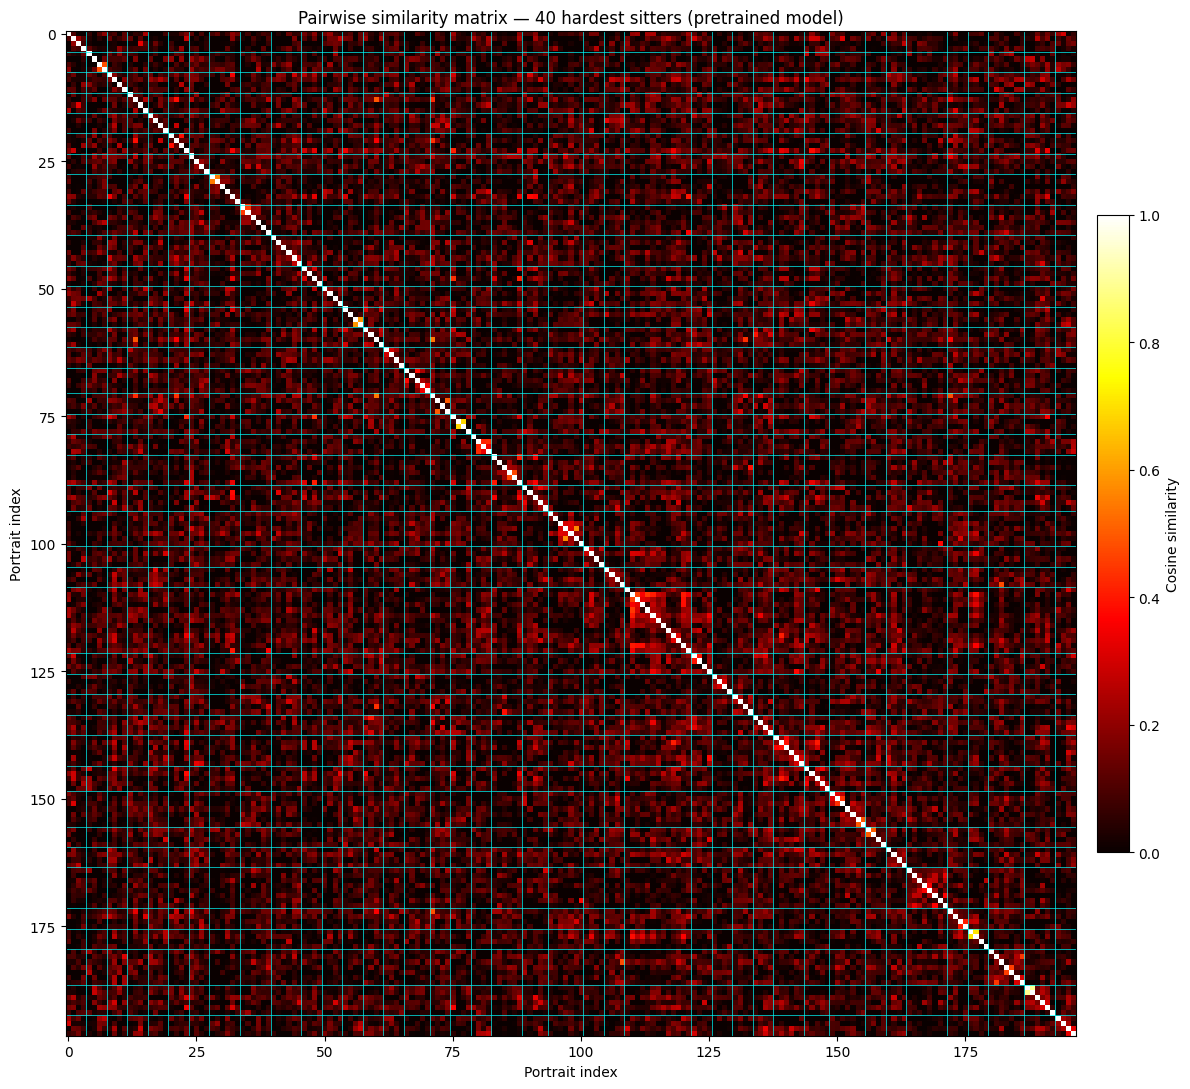

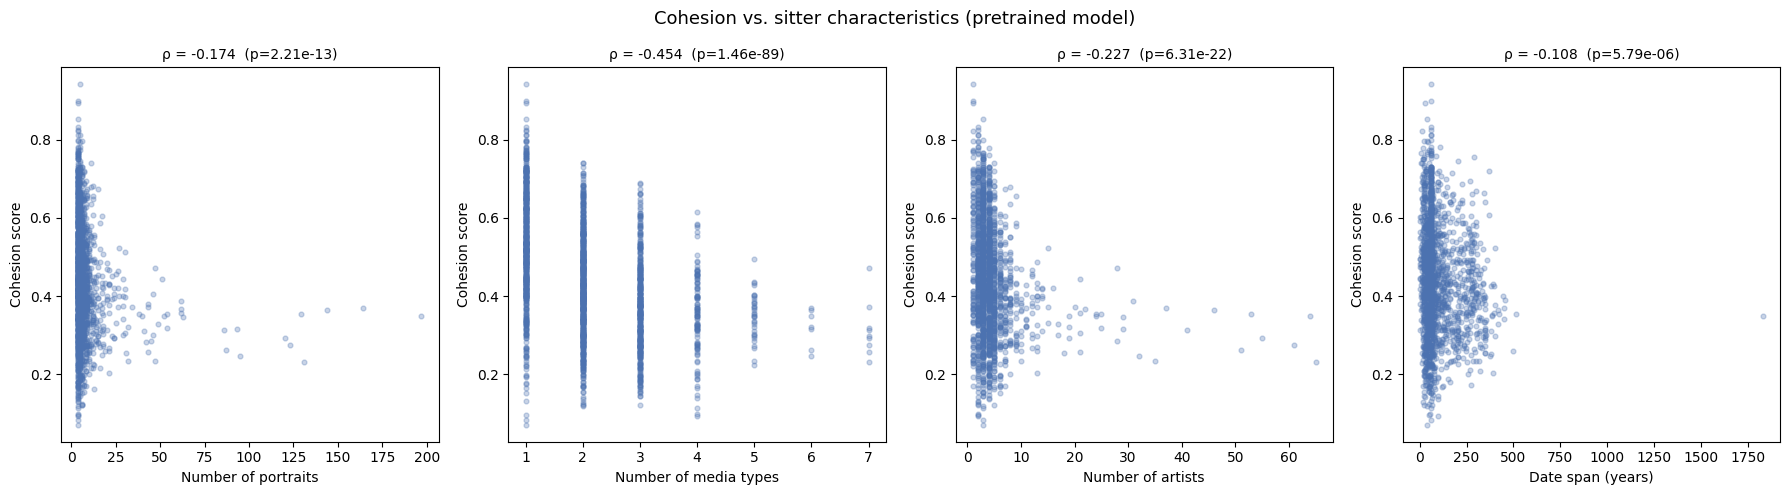

In [88]:
from scipy.stats import spearmanr

MIN_PORTRAITS = 4
VIZ_N         = 40

# Filter to sitters with ≥ MIN_PORTRAITS portraits
sitter_counts = df.groupby('sitter_id')['lref'].count()
eligible      = set(sitter_counts[sitter_counts >= MIN_PORTRAITS].index)
df_s          = df[df['sitter_id'].isin(eligible)].copy()
df_s['zoekmarge_begindatum'] = pd.to_numeric(df_s['zoekmarge_begindatum'], errors='coerce')
df_s['zoekmarge_einddatum']  = pd.to_numeric(df_s['zoekmarge_einddatum'],  errors='coerce')
print(f"Sitters with ≥{MIN_PORTRAITS} portraits: {len(eligible):,}")
print(f"Portraits in filtered set: {len(df_s):,}")

# Build per-sitter metadata
def _year_span(grp):
    lo = df_s.loc[grp.index, 'zoekmarge_begindatum'].dropna()
    hi = df_s.loc[grp.index, 'zoekmarge_einddatum'].dropna()
    if lo.empty or hi.empty:
        return float('nan')
    return float(hi.max() - lo.min())

meta = (df_s.groupby('sitter_id').agg(
    n_portraits=('lref',              'count'),
    n_media    =('medium_group',      'nunique'),
    n_artists  =('artist_id',         lambda x: x.dropna().nunique()),
    year_span  =('zoekmarge_begindatum', _year_span),
).reset_index())

# Compute cohesion score: mean pairwise cosine similarity within sitter
cohesion = {}
for sid, grp in df_s.groupby('sitter_id'):
    lrefs  = grp['lref'].astype(str).tolist()
    scores = []
    for la, lb in itr_combinations(lrefs, 2):
        ea = emb_pretrained.get(la)
        eb = emb_pretrained.get(lb)
        if ea is None or eb is None:
            continue
        scores.append(float(np.dot(ea, eb)))
    if scores:
        cohesion[sid] = float(np.mean(scores))

meta['cohesion'] = meta['sitter_id'].map(cohesion)
meta = meta.dropna(subset=['cohesion']).sort_values('cohesion').reset_index(drop=True)

print(f"\nSitters with cohesion score: {len(meta):,}")
print(f"Cohesion  mean={meta['cohesion'].mean():.4f}  "
      f"median={meta['cohesion'].median():.4f}  "
      f"std={meta['cohesion'].std():.4f}")

# Summary tables: hardest and easiest sitters
print("\n--- Hardest 15 sitters (lowest cohesion) ---")
display(meta.head(15)[['sitter_id', 'cohesion', 'n_portraits', 'n_media', 'n_artists', 'year_span']]
        .style.format({'cohesion': '{:.4f}', 'year_span': '{:.0f}'}))

print("\n--- Easiest 15 sitters (highest cohesion) ---")
display(meta.tail(15)[['sitter_id', 'cohesion', 'n_portraits', 'n_media', 'n_artists', 'year_span']]
        .sort_values('cohesion', ascending=False)
        .style.format({'cohesion': '{:.4f}', 'year_span': '{:.0f}'}))

# ── Pairwise similarity matrix: VIZ_N hardest sitters ──────────────────────────
hardest     = meta.head(VIZ_N)
viz_sitters = hardest['sitter_id'].tolist()

# Collect portraits for hardest sitters, sorted by cohesion then medium
viz_df = (df_s[df_s['sitter_id'].isin(viz_sitters)]
          .merge(hardest[['sitter_id', 'cohesion']], on='sitter_id')
          .sort_values(['cohesion', 'sitter_id', 'medium_group'])
          .reset_index(drop=True))

viz_lrefs = viz_df['lref'].astype(str).tolist()
viz_sids  = viz_df['sitter_id'].tolist()

# Build embedding matrix (skip portraits with no embedding)
E, valid_sids = [], []
for lr, sid in zip(viz_lrefs, viz_sids):
    e = emb_pretrained.get(lr)
    if e is not None:
        E.append(e)
        valid_sids.append(sid)
E = np.stack(E)
sim_matrix = E @ E.T  # cosine similarity (L2-normalised)

# Sitter boundary positions
boundaries = []
prev = None
for j, sid in enumerate(valid_sids):
    if sid != prev:
        if prev is not None:
            boundaries.append(j - 0.5)
        prev = sid

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(sim_matrix, cmap='hot', vmin=0, vmax=1, aspect='auto')
for b in boundaries:
    ax.axhline(b, color='cyan', lw=0.6, alpha=0.8)
    ax.axvline(b, color='cyan', lw=0.6, alpha=0.8)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Cosine similarity')
ax.set_title(f'Pairwise similarity matrix — {VIZ_N} hardest sitters (pretrained model)', fontsize=12)
ax.set_xlabel('Portrait index')
ax.set_ylabel('Portrait index')
plt.tight_layout()
plt.show()

# ── Scatter plots: cohesion vs sitter characteristics ──────────────────────────
features = [
    ('n_portraits', 'Number of portraits'),
    ('n_media',     'Number of media types'),
    ('n_artists',   'Number of artists'),
    ('year_span',   'Date span (years)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (col, label) in zip(axes, features):
    sub = meta.dropna(subset=[col, 'cohesion'])
    r, p = spearmanr(sub[col], sub['cohesion'])
    ax.scatter(sub[col], sub['cohesion'], alpha=0.3, s=12, color='#4C72B0')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Cohesion score', fontsize=10)
    ax.set_title(f'ρ = {r:.3f}  (p={p:.3g})', fontsize=10)
plt.suptitle('Cohesion vs. sitter characteristics (pretrained model)', fontsize=13)
plt.tight_layout()
plt.show()

---
## RQ2: CLIP+LoRA Foundation Model Performance

Embeddings at `D:/thesis/Swiss_team_rerun_embeddings/`:

| Variable | File | Model | Dim |
|----------|------|-------|-----|
| `emb_ires_pre` | `ires100_embeddings.npy` | IResNet100 pretrained (Glint360k) | 512 |
| `emb_ires_rkd` | `ires100_rkd_embeddings.npy` | IResNet100 fine-tuned on RKD | 512 |
| `emb_clip_base` | `clip_embeddings.npy` | CLIP ViT-B/16, no LoRA | 768 |
| `emb_clip_lora` | `clip_rkd_embeddings.npy` | CLIP ViT-B/16 + LoRA (RKD) | 768 |
| `emb_fusion` | `fusion_rkd_embeddings.npy` | Poh et al. 3-component fusion (IRes pre + IRes ft + CLIP LoRA) | 1792 |

All embeddings are L2-normalised; cosine similarity = dot product. Keys in .npy dicts: `'data/paintings/{sitter_id}_{lref}.jpg'`.

In [89]:
%matplotlib inline

from pathlib import Path

EMB_DIR = Path('D:/thesis/Swiss_team_rerun_embeddings')

def load_npy_emb(path):
    """Load Swiss-team .npy embedding dict.
    Keys: 'data/paintings/{sitter_id}_{lref}.jpg' → float32 array.
    Returns dict: lref (str) → L2-normalised embedding.
    """
    raw   = np.load(str(path), allow_pickle=True).item()
    keys  = list(raw.keys())
    vecs  = normalize(np.stack([raw[k].astype(np.float32) for k in keys]), norm='l2')
    lrefs = [Path(k).stem.split('_', 1)[1] for k in keys]
    return dict(zip(lrefs, vecs))

emb_ires_pre  = load_npy_emb(EMB_DIR / 'ires100_embeddings.npy')
emb_ires_rkd  = load_npy_emb(EMB_DIR / 'ires100_rkd_v2_embeddings.npy')
emb_clip_base = load_npy_emb(EMB_DIR / 'clip_embeddings.npy')
emb_clip_lora = load_npy_emb(EMB_DIR / 'clip_rkd_v2_embeddings.npy')
emb_fusion    = load_npy_emb(EMB_DIR / 'fusion_rkd_v2_embeddings.npy')

for name, emb in [('IRes pretrained',  emb_ires_pre), ('IRes fine-tuned', emb_ires_rkd),
                   ('CLIP base',       emb_clip_base), ('CLIP + LoRA',    emb_clip_lora),
                   ('Fusion',          emb_fusion)]:
    dim = next(iter(emb.values())).shape[0]
    print(f'{name:20s}: {len(emb):,} embeddings, dim={dim}')


IRes pretrained     : 27,337 embeddings, dim=512
IRes fine-tuned     : 27,337 embeddings, dim=512
CLIP base           : 27,337 embeddings, dim=768
CLIP + LoRA         : 27,337 embeddings, dim=768
Fusion              : 27,337 embeddings, dim=1792


---
### RQ2-a: Poh et al. fusion model — overall performance on RKD

Does the 3-component CLIP+LoRA fusion model outperform the IResNet100 baseline on the full RKD dataset?

Same pair protocol as RQ1 (full dataset, 1:10 impostor ratio, seed=42).
Reports AUC, Macro-AUC (per-sitter averaged), EER, TAR@1% FAR, TAR@0.1% FAR for all five models, plus ROC curves and score distributions.

Pairs built — genuine: 168,546  impostor: 1,685,460  ratio: 1:10


,Model,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,IResNet100 pretrained,0.9383,0.9513,0.1363,0.5944,0.3836
1,IResNet100 fine-tuned,0.9694,0.9435,0.0891,0.8071,0.6852
2,CLIP base (no LoRA),0.8241,0.9138,0.2456,0.2226,0.0793
3,CLIP + LoRA,0.8910,0.8861,0.1951,0.4378,0.1872
4,Fusion (3-component),0.9727,0.9573,0.0831,0.7960,0.6141


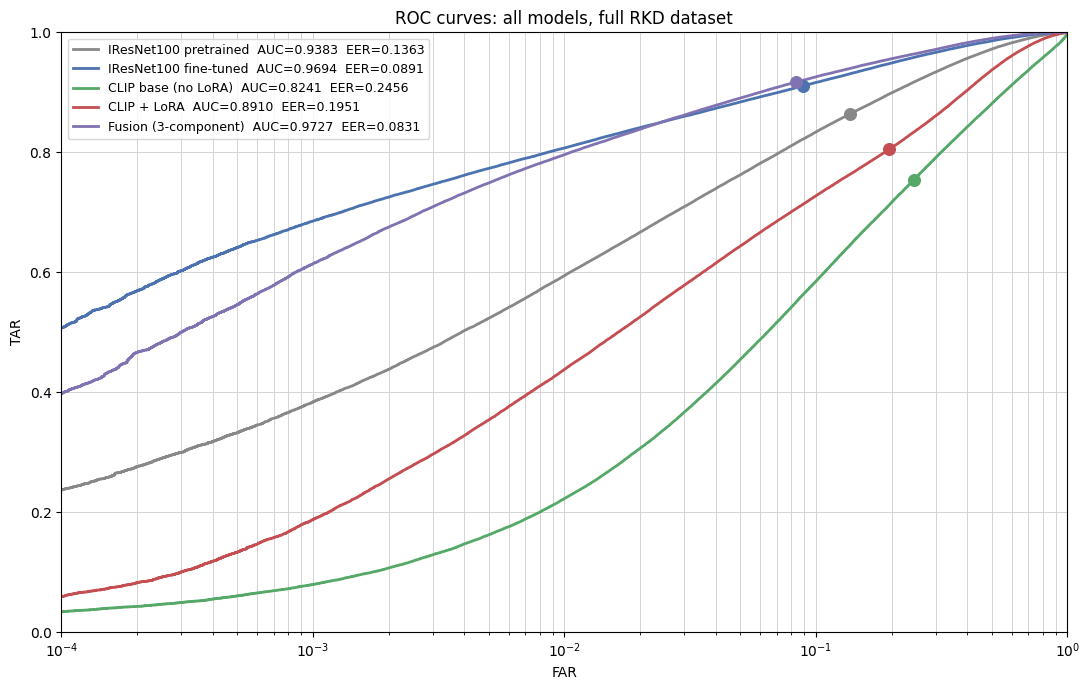

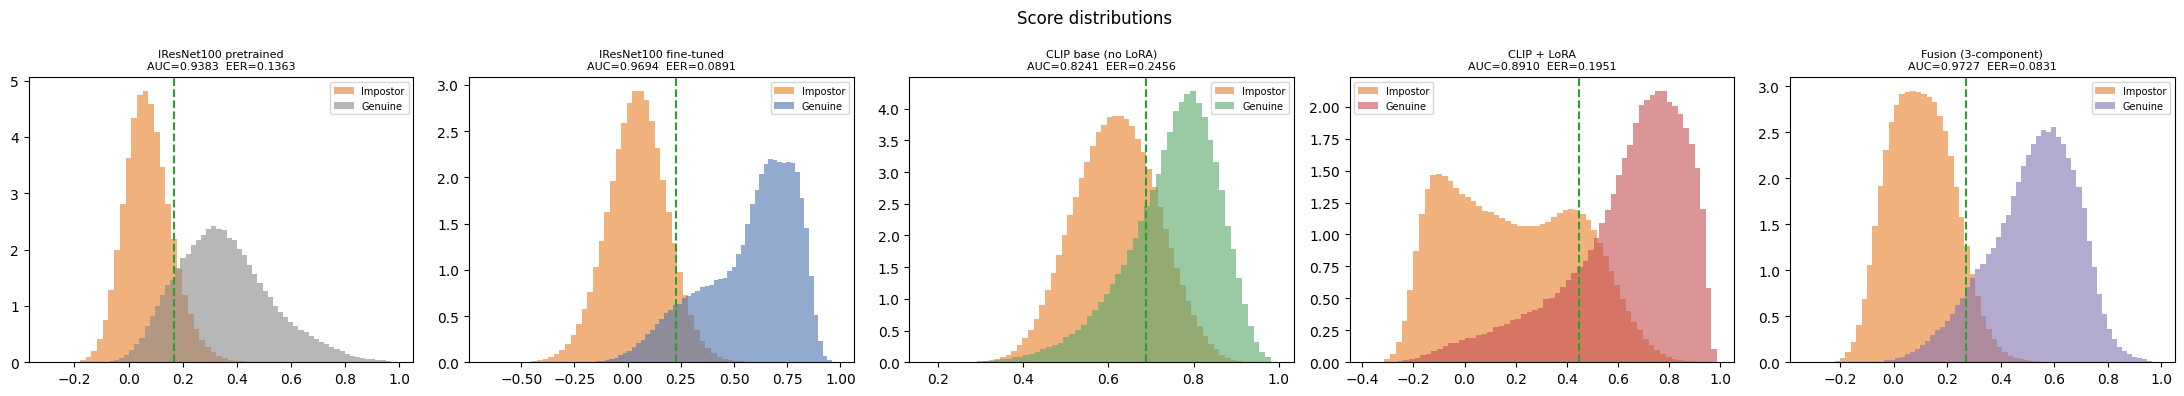

In [101]:
pairs_full = build_pairs(df, impostor_ratio=10, seed=42)

RQ2A_MODELS = [
    ('IResNet100 pretrained', emb_ires_pre),
    ('IResNet100 fine-tuned', emb_ires_rkd),
    ('CLIP base (no LoRA)',   emb_clip_base),
    ('CLIP + LoRA',           emb_clip_lora),
    ('Fusion (3-component)',  emb_fusion),
]

PALETTE = ['#888888', '#4C72B0', '#55A868', '#C44E52', '#8172B2']

rq2a_results = {}
for name, emb in RQ2A_MODELS:
    sc, lb, sa, sb     = score_pairs(pairs_full, emb)
    rq2a_results[name] = compute_metrics(sc, lb, sa, sb)

# ── Metric table ──────────────────────────────────────────────────────────────
rows = [{'Model': name, 'AUC': m['AUC'], 'Macro-AUC': m['macro_AUC'],
         'EER': m['EER'], 'TAR@1%': m['TAR@1%'], 'TAR@0.1%': m['TAR@0.1%']}
        for name, m in rq2a_results.items()]
display(pd.DataFrame(rows).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
}))

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for (name, m), c in zip(rq2a_results.items(), PALETTE):
    ax.plot(m['_fpr'], m['_tpr'], color=c, lw=2,
            label=f"{name}  AUC={m['AUC']:.4f}  EER={m['EER']:.4f}")
    ax.scatter([m['EER']], [1 - m['EER']], color=c, s=70, zorder=5)
ax.set_xscale('log'); ax.set_xlim([1e-4, 1]); ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR'); ax.set_ylabel('TAR')
ax.set_title('ROC curves: all models, full RKD dataset')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

# ── Score distributions ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(RQ2A_MODELS), figsize=(22, 4))
for ax, ((name, m), c) in zip(axes, zip(rq2a_results.items(), PALETTE)):
    gen = m['_scores'][m['_labels'] == 1]
    imp = m['_scores'][m['_labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label='Impostor')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color=c,          label='Genuine')
    ax.axvline(m['EER_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(f'{name}\nAUC={m["AUC"]:.4f}  EER={m["EER"]:.4f}', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Score distributions', fontsize=12)
plt.tight_layout(); plt.show()

---
### RQ2-b: Medium gap — EXP8 & EXP9

Does the fusion model close the performance gap between media types?

- **EXP8**: replicates EXP1 exactly (stratified by medium group), evaluated on the **Fusion** model only — metric table, combined ROC curve, and per-medium score distributions.
- **EXP9**: replicates EXP2 exactly (cross-medium genuine pairs), evaluated on the **Fusion** model only — same output format.

Hypothesis: if the fusion model generalises better across media than a face-specific model trained on photographs, the medium gap visible in EXP1/EXP2 (pretrained model) should narrow here.

Pairs built — genuine: 35,044  impostor: 350,440  ratio: 1:10
Pairs built — genuine: 12,190  impostor: 121,900  ratio: 1:10
Pairs built — genuine: 24,670  impostor: 246,700  ratio: 1:10
Pairs built — genuine: 3,061  impostor: 30,610  ratio: 1:10
Pairs built — genuine: 513  impostor: 5,130  ratio: 1:10
Pairs built — genuine: 593  impostor: 5,930  ratio: 1:10
Pairs built — genuine: 43  impostor: 430  ratio: 1:10


,Medium,Portraits,Sitters,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings,"9,613","4,416",0.9858,0.9657,0.0576,0.8460,0.6579
1,Photographs,"7,557","2,978",0.9786,0.9752,0.0671,0.8706,0.7893
2,Prints,"4,698","1,547",0.9662,0.9635,0.0955,0.6749,0.4274
3,Drawings,"3,644","2,311",0.9482,0.9268,0.1177,0.6158,0.4156
4,Portrait miniatures,"1,036",769,0.9511,0.9319,0.1224,0.6940,0.6043
5,Sculpture,491,302,0.9225,0.9198,0.1556,0.6206,0.4654
6,Other,298,260,0.8604,0.8391,0.2163,0.1395,0.0465


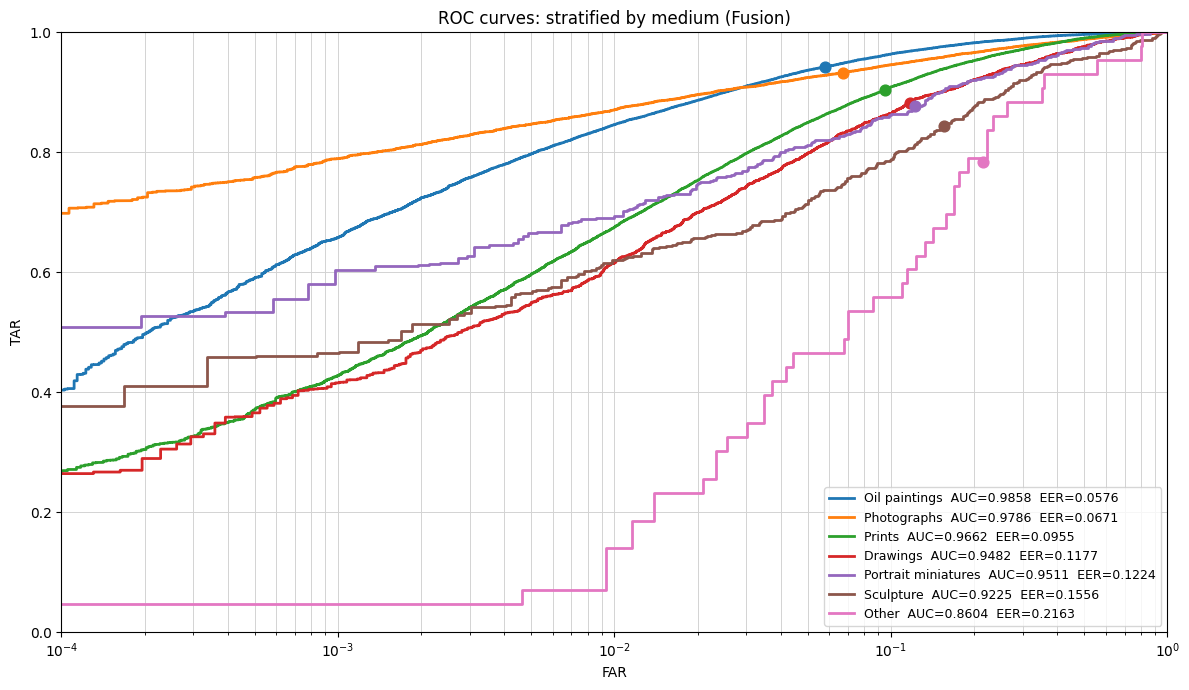

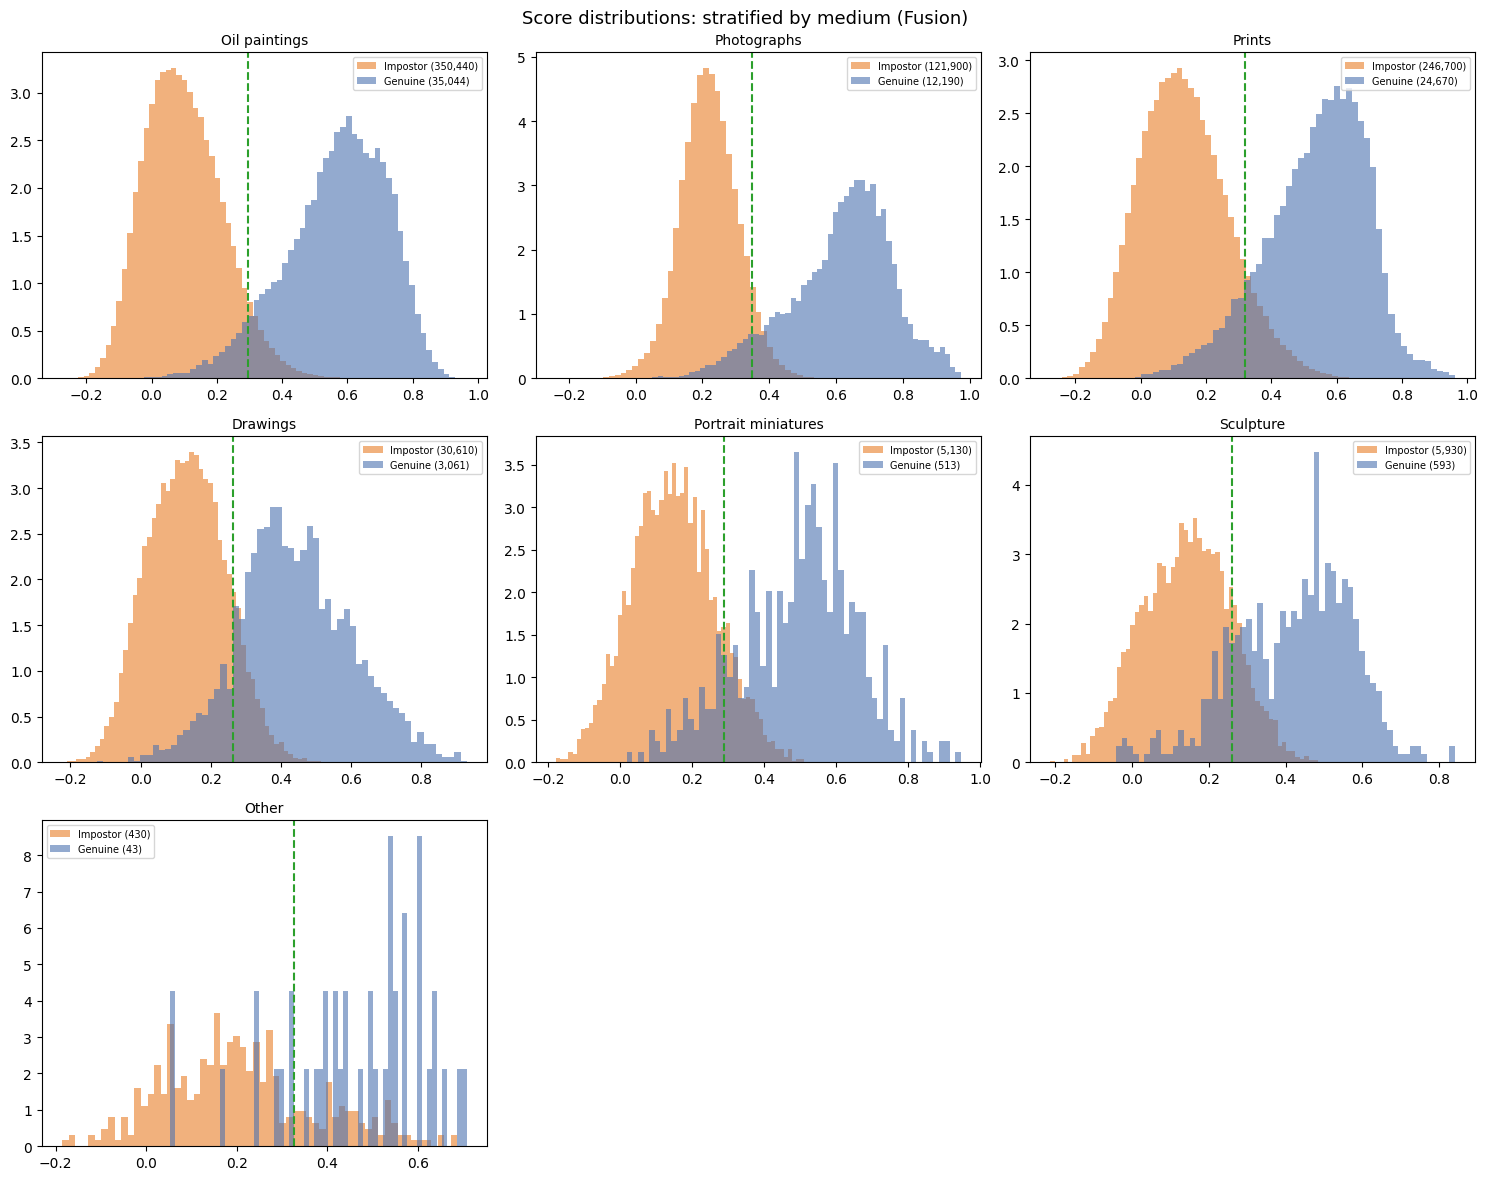

In [102]:
# EXP8: replicate EXP1 (stratified by medium group) — Fusion model only

media_8 = (df.groupby('medium_group')['lref']
             .count()
             .sort_values(ascending=False)
             .index.tolist())

rows_8, roc_entries_8 = [], []

for medium in media_8:
    subset = df[df['medium_group'] == medium]
    if subset['sitter_id'].nunique() < 2:
        continue
    pairs          = build_pairs(subset, impostor_ratio=10, seed=42)
    sc, lb, sa, sb = score_pairs(pairs, emb_fusion)
    m              = compute_metrics(sc, lb, sa, sb)
    rows_8.append({
        'Medium':    medium,
        'Portraits': len(subset),
        'Sitters':   subset['sitter_id'].nunique(),
        'AUC':       m['AUC'],
        'Macro-AUC': m['macro_AUC'],
        'EER':       m['EER'],
        'TAR@1%':    m['TAR@1%'],
        'TAR@0.1%':  m['TAR@0.1%'],
    })
    roc_entries_8.append({'label': medium, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                          'auc': m['AUC'], 'eer': m['EER'],
                          'scores': m['_scores'], 'labels': m['_labels'],
                          'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows_8).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'Portraits': '{:,}', 'Sitters': '{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries_8):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2,
            label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: stratified by medium (Fusion)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

n = len(roc_entries_8)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries_8):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions: stratified by medium (Fusion)', fontsize=13)
plt.tight_layout()
plt.show()

  Cross-medium (Oil paintings × Prints) — shared sitters: 937  genuine: 43,234  impostor: 432,340
  Cross-medium (Oil paintings × Drawings) — shared sitters: 1,357  genuine: 8,894  impostor: 88,940
  Cross-medium (Oil paintings × Photographs) — shared sitters: 614  genuine: 5,315  impostor: 53,150
  Cross-medium (Drawings × Prints) — shared sitters: 448  genuine: 4,961  impostor: 49,610
  Cross-medium (Photographs × Prints) — shared sitters: 152  genuine: 3,496  impostor: 34,960
  Cross-medium (Drawings × Photographs) — shared sitters: 362  genuine: 2,118  impostor: 21,180


,Combination,Genuine,Impostor,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Oil paintings x Prints,"43,234","432,340",0.9769,0.9496,0.0772,0.7878,0.5734
1,Oil paintings x Drawings,"8,894","88,940",0.9572,0.9311,0.1068,0.6950,0.4973
2,Oil paintings x Photographs,"5,315","53,150",0.9648,0.9583,0.1040,0.8179,0.7471
3,Drawings x Prints,"4,961","49,610",0.9559,0.9413,0.1117,0.6982,0.4527
4,Photographs x Prints,"3,496","34,960",0.9654,0.9727,0.1064,0.7397,0.6316
5,Drawings x Photographs,"2,118","21,180",0.9335,0.9247,0.1390,0.7063,0.5859


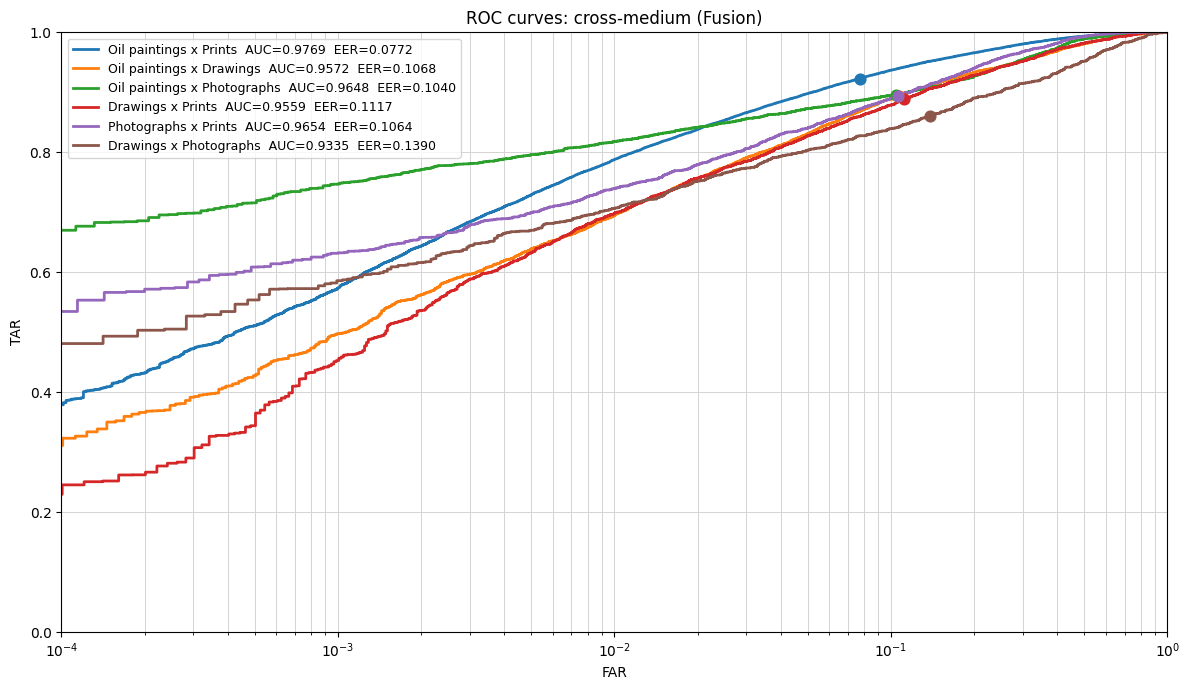

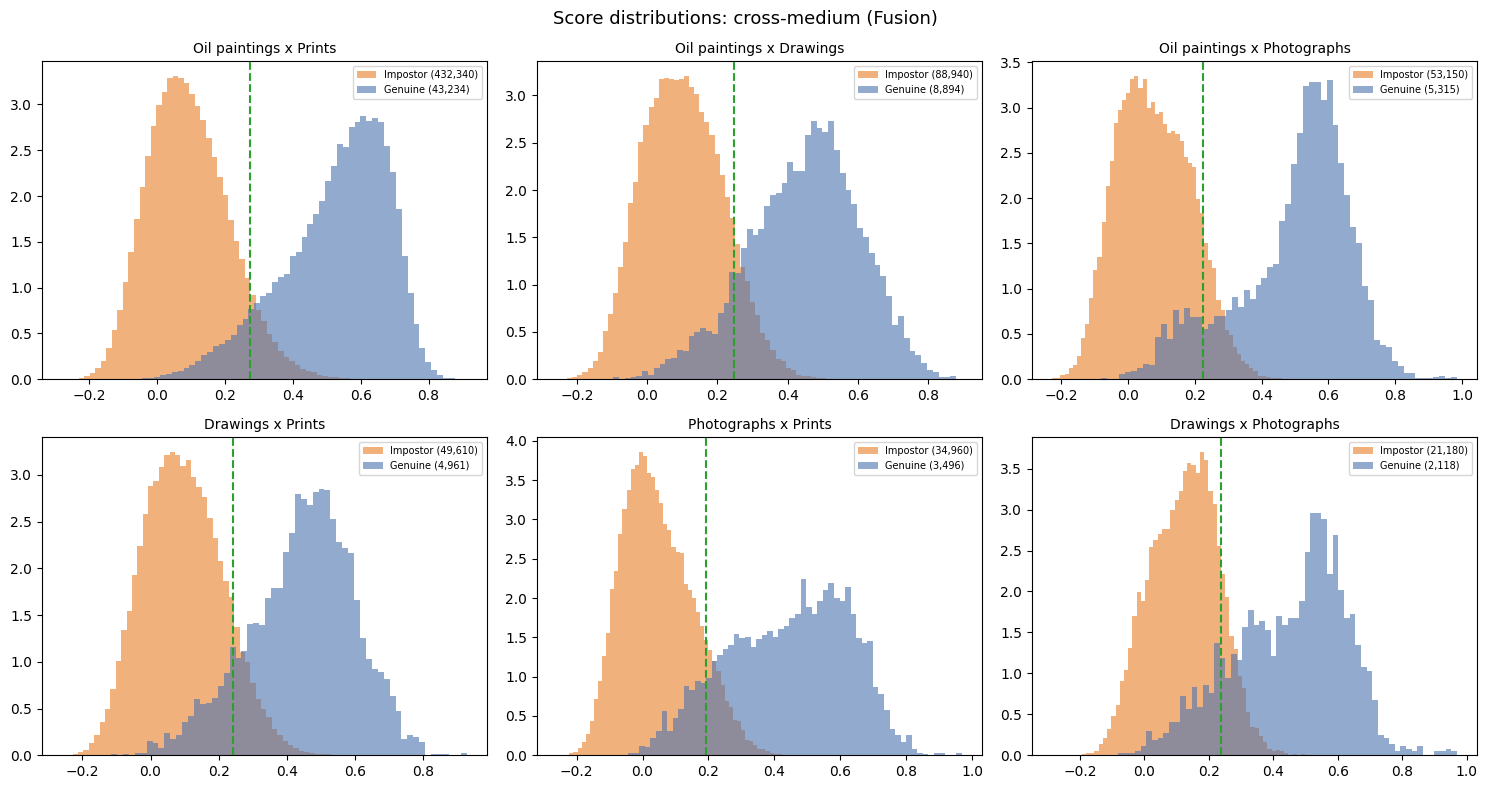

In [103]:
# EXP9: replicate EXP2 (cross-medium genuine pairs) — Fusion model only

cross_combos_9 = [
    ('Oil paintings', 'Prints'),
    ('Oil paintings', 'Drawings'),
    ('Oil paintings', 'Photographs'),
    ('Drawings',      'Prints'),
    ('Photographs',   'Prints'),
    ('Drawings',      'Photographs'),
]

rows_9, roc_entries_9 = [], []

for med_a, med_b in cross_combos_9:
    pairs          = build_cross_medium_pairs(df, 'medium_group', med_a, med_b,
                                              impostor_ratio=10, seed=42)
    if not pairs:
        continue
    sc, lb, sa, sb = score_pairs(pairs, emb_fusion)
    m              = compute_metrics(sc, lb, sa, sb)
    label          = f'{med_a} x {med_b}'
    rows_9.append({
        'Combination': label,
        'Genuine':     int(lb.sum()),
        'Impostor':    int((lb == 0).sum()),
        'AUC':         m['AUC'],
        'Macro-AUC':   m['macro_AUC'],
        'EER':         m['EER'],
        'TAR@1%':      m['TAR@1%'],
        'TAR@0.1%':    m['TAR@0.1%'],
    })
    roc_entries_9.append({'label': label, 'fpr': m['_fpr'], 'tpr': m['_tpr'],
                          'auc': m['AUC'], 'eer': m['EER'],
                          'scores': m['_scores'], 'labels': m['_labels'],
                          'eer_thr': m['EER_thr']})

display(pd.DataFrame(rows_9).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'Genuine': '{:,}', 'Impostor': '{:,}',
}))

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(12, 7))
for i, e in enumerate(roc_entries_9):
    c = colors[i % 10]
    ax.plot(e['fpr'], e['tpr'], color=c, lw=2,
            label=f"{e['label']}  AUC={e['auc']:.4f}  EER={e['eer']:.4f}")
    ax.scatter([e['eer']], [1 - e['eer']], color=c, s=60, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: cross-medium (Fusion)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

n = len(roc_entries_9)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, e in enumerate(roc_entries_9):
    ax  = axes[i]
    gen = e['scores'][e['labels'] == 1]
    imp = e['scores'][e['labels'] == 0]
    ax.hist(imp, bins=60, density=True, alpha=0.6, color='#E87D27', label=f'Impostor ({len(imp):,})')
    ax.hist(gen, bins=60, density=True, alpha=0.6, color='#4C72B0', label=f'Genuine ({len(gen):,})')
    ax.axvline(e['eer_thr'], color='#2CA02C', linestyle='--', lw=1.5)
    ax.set_title(e['label'], fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Score distributions: cross-medium (Fusion)', fontsize=13)
plt.tight_layout()
plt.show()

---
### RQ2-c: Artist bias — EXP10 & EXP11

Does the fusion model reduce artist bias relative to the pretrained baseline (EXP5a/EXP6)?

- **EXP10**: replicates EXP5a exactly (within-artist vs. cross-artist impostor scores), evaluated on the **Fusion** model only — summary table, Mann-Whitney U test, per-artist mean histogram, and top-20 boxplot.
- **EXP11**: replicates EXP6 exactly (within-artist vs. cross-artist genuine pairs), evaluated on the **Fusion** model only — summary table, Mann-Whitney U test, score-distribution plot, and ROC comparison.

Both cells reuse the pair sets built in EXP5a (cell-20) and EXP6 (cell-24); only the scoring model changes.

,Group,N artists,Mean,Median,Std
0,Within-artist impostors,658,0.2344,0.2324,0.0556
1,Cross-artist impostors,658,0.1032,0.1083,0.0228



Mann-Whitney U (within > cross): U=429640.0,  p=0.0000
--> Within-artist impostor scores are significantly higher (artist bias detected)


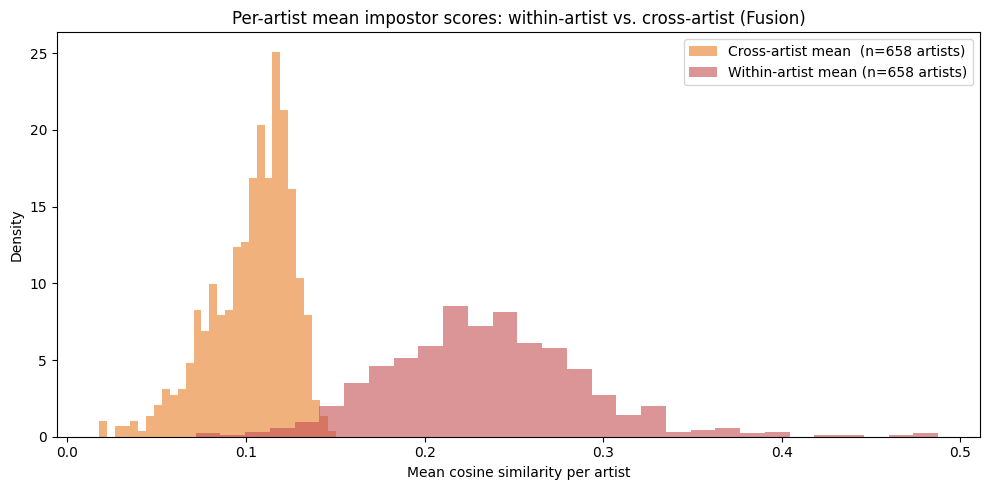

C:\Users\jenne\AppData\Local\Temp\ipykernel_40980\493730871.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data_10, labels=box_labels_10, vert=True)


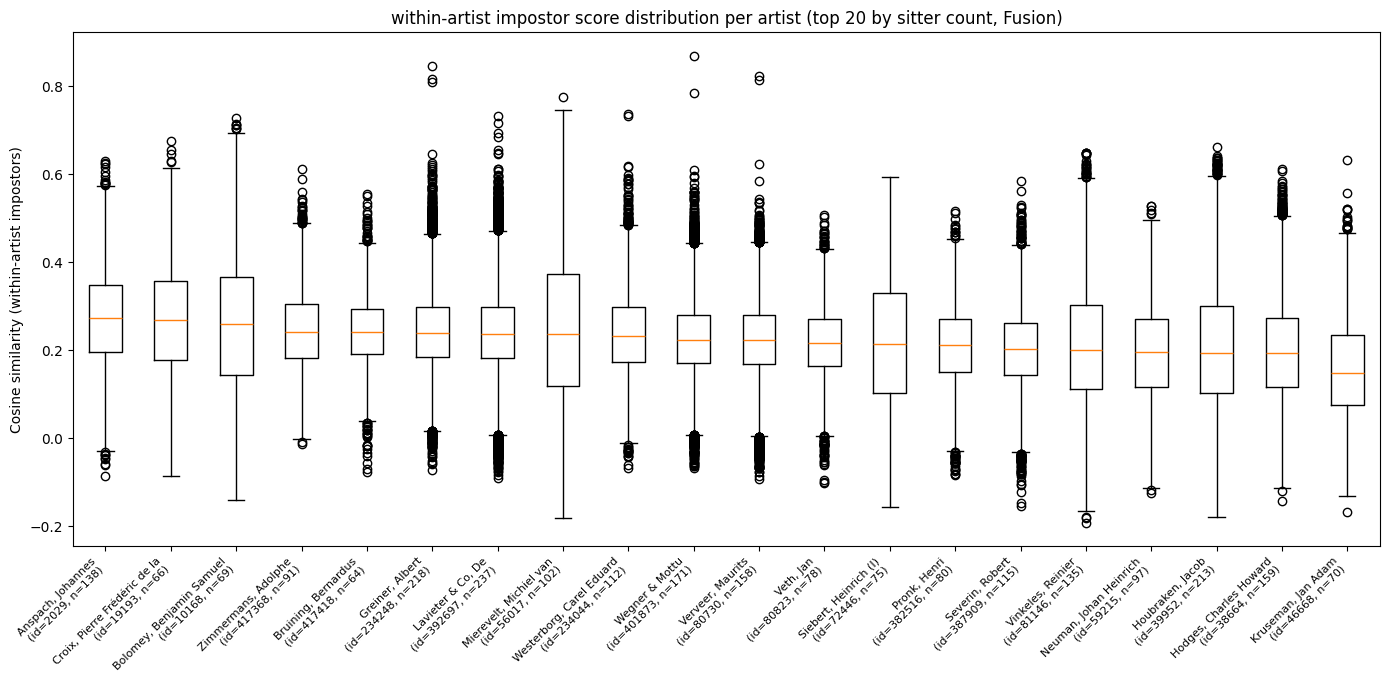

In [104]:
# EXP10: replicate EXP5a (within-artist vs. cross-artist impostor scores) — Fusion model only
# Reuses within_pairs, cross_pairs, qualifying, artist_sitter_counts, df5, score_artist_pairs from EXP5a (cell-20).

within_scores_10, within_artist_ids_10 = score_artist_pairs(within_pairs, emb_fusion)
cross_scores_10,  cross_artist_ids_10  = score_artist_pairs(cross_pairs,  emb_fusion)

within_means_10 = {aid: float(np.mean(within_scores_10[within_artist_ids_10 == aid]))
                   for aid in qualifying if (within_artist_ids_10 == aid).sum() > 0}
cross_means_10  = {aid: float(np.mean(cross_scores_10[cross_artist_ids_10 == aid]))
                   for aid in qualifying if (cross_artist_ids_10 == aid).sum() > 0}

common_10 = set(within_means_10) & set(cross_means_10)
wm_10 = np.array([within_means_10[a] for a in common_10])
cm_10 = np.array([cross_means_10[a]  for a in common_10])

# Summary table
display(pd.DataFrame({
    'Group':        ['Within-artist impostors', 'Cross-artist impostors'],
    'N artists':    [len(within_means_10), len(cross_means_10)],
    'Mean':         [round(float(np.mean(wm_10)), 4),   round(float(np.mean(cm_10)), 4)],
    'Median':       [round(float(np.median(wm_10)), 4), round(float(np.median(cm_10)), 4)],
    'Std':          [round(float(np.std(wm_10)), 4),    round(float(np.std(cm_10)), 4)],
}))

stat10, p10 = mannwhitneyu(wm_10, cm_10, alternative='greater')
print(f"\nMann-Whitney U (within > cross): U={stat10:.1f},  p={p10:.4f}")
if p10 < 0.05:
    print("--> Within-artist impostor scores are significantly higher (artist bias detected)")
else:
    print("--> No significant difference (no strong artist bias)")

# Plot: histogram of per-artist means
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cm_10, bins=30, density=True, alpha=0.6, color='#E87D27',
        label=f'Cross-artist mean  (n={len(cm_10)} artists)')
ax.hist(wm_10, bins=30, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist mean (n={len(wm_10)} artists)')
ax.set_xlabel('Mean cosine similarity per artist')
ax.set_ylabel('Density')
ax.set_title('Per-artist mean impostor scores: within-artist vs. cross-artist (Fusion)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot: per-artist boxplot (top 20 by sitter count, sorted by median)
top20_ids_10 = (artist_sitter_counts[artist_sitter_counts.index.isin(qualifying)]
                .sort_values(ascending=False).head(20).index.tolist())
artist_id_to_name_10 = df5.drop_duplicates('artist_id').set_index('artist_id')['artist_name'].to_dict()

box_data_10, box_labels_10, box_medians_10 = [], [], []
for aid in top20_ids_10:
    mask = within_artist_ids_10 == aid
    if mask.sum() == 0:
        continue
    d    = within_scores_10[mask]
    name = artist_id_to_name_10.get(aid, str(aid))
    box_data_10.append(d)
    box_labels_10.append(f"{name[:28]}\n(id={aid}, n={artist_sitter_counts[aid]})")
    box_medians_10.append(float(np.median(d)))

order_10      = np.argsort(box_medians_10)[::-1]
box_data_10   = [box_data_10[i]   for i in order_10]
box_labels_10 = [box_labels_10[i] for i in order_10]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data_10, labels=box_labels_10, vert=True)
ax.set_ylabel('Cosine similarity (within-artist impostors)')
ax.set_title('within-artist impostor score distribution per artist (top 20 by sitter count, Fusion)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

,Condition,N genuine,N impostor,AUC,Macro-AUC,EER,TAR@1%,TAR@0.1%
0,Within-artist genuine,"28,595","131,600",0.9820,0.9843,0.0647,0.8305,0.6803
1,Cross-artist genuine,"139,951","131,600",0.9706,0.9519,0.0875,0.7866,0.6187



Mann-Whitney U (within genuine > cross genuine): U=2291033344.0,  p=0.0000
--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)


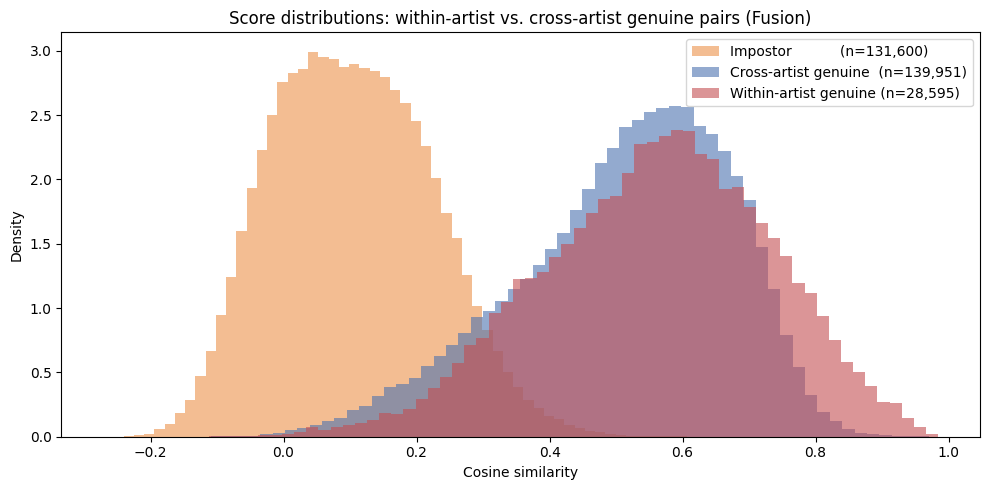

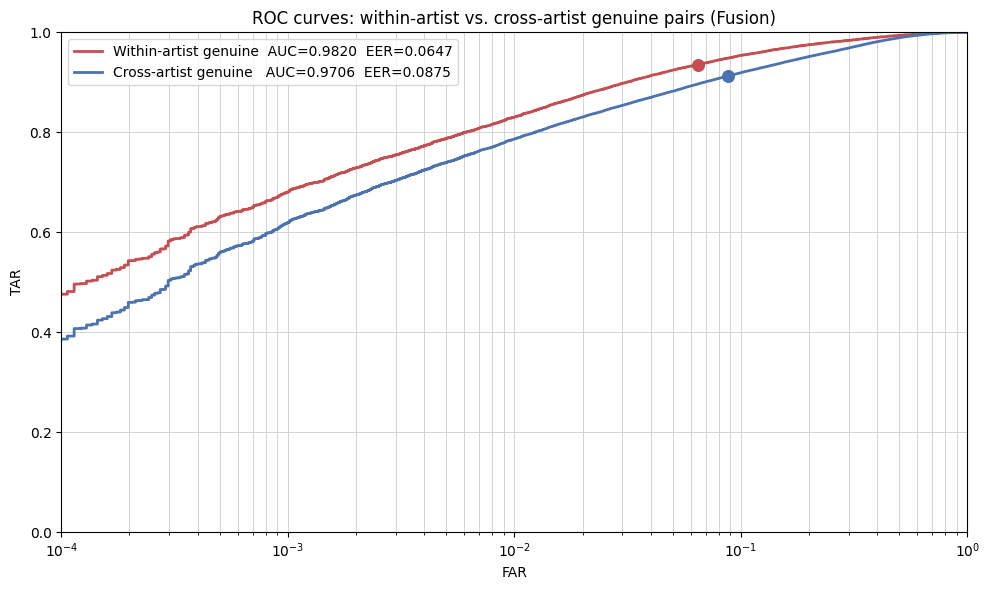

In [106]:
# EXP11: replicate EXP6 (within-artist vs. cross-artist genuine pairs) — Fusion model only
# Reuses within_genuine, cross_genuine, impostor_pairs_6 from EXP6 (cell-24).

sc_w11, lb_w11, sa_w11, sb_w11 = score_pairs(within_genuine + impostor_pairs_6, emb_fusion)
sc_c11, lb_c11, sa_c11, sb_c11 = score_pairs(cross_genuine  + impostor_pairs_6, emb_fusion)

m_w11 = compute_metrics(sc_w11, lb_w11, sa_w11, sb_w11)
m_c11 = compute_metrics(sc_c11, lb_c11, sa_c11, sb_c11)

# Summary table
display(pd.DataFrame([
    {'Condition':  'Within-artist genuine',
     'N genuine':  int(lb_w11.sum()), 'N impostor': int((lb_w11 == 0).sum()),
     'AUC':        m_w11['AUC'],  'Macro-AUC': m_w11['macro_AUC'],
     'EER':        m_w11['EER'],  'TAR@1%':    m_w11['TAR@1%'], 'TAR@0.1%': m_w11['TAR@0.1%']},
    {'Condition':  'Cross-artist genuine',
     'N genuine':  int(lb_c11.sum()), 'N impostor': int((lb_c11 == 0).sum()),
     'AUC':        m_c11['AUC'],  'Macro-AUC': m_c11['macro_AUC'],
     'EER':        m_c11['EER'],  'TAR@1%':    m_c11['TAR@1%'], 'TAR@0.1%': m_c11['TAR@0.1%']},
]).style.format({
    'AUC': '{:.4f}', 'Macro-AUC': '{:.4f}', 'EER': '{:.4f}',
    'TAR@1%': '{:.4f}', 'TAR@0.1%': '{:.4f}',
    'N genuine': '{:,}', 'N impostor': '{:,}',
}))

# Mann-Whitney U: within-genuine scores > cross-genuine scores
gen_w11 = sc_w11[lb_w11 == 1]
gen_c11 = sc_c11[lb_c11 == 1]
stat11, p11 = mannwhitneyu(gen_w11, gen_c11, alternative='greater')
print(f"\nMann-Whitney U (within genuine > cross genuine): U={stat11:.1f},  p={p11:.4f}")
if p11 < 0.05:
    print("--> Within-artist genuine pairs score significantly higher (style shortcut confirmed)")
else:
    print("--> No significant difference")

# Plot 1: 3-way score distribution
imp_scores11 = sc_w11[lb_w11 == 0]  # same impostor pool for both conditions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(imp_scores11, bins=60, density=True, alpha=0.5, color='#E87D27',
        label=f'Impostor           (n={len(imp_scores11):,})')
ax.hist(gen_c11, bins=60, density=True, alpha=0.6, color='#4C72B0',
        label=f'Cross-artist genuine  (n={len(gen_c11):,})')
ax.hist(gen_w11, bins=60, density=True, alpha=0.6, color='#C44E52',
        label=f'Within-artist genuine (n={len(gen_w11):,})')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Score distributions: within-artist vs. cross-artist genuine pairs (Fusion)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: ROC curve comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(m_w11['_fpr'], m_w11['_tpr'], color='#C44E52', lw=2,
        label=f"Within-artist genuine  AUC={m_w11['AUC']:.4f}  EER={m_w11['EER']:.4f}")
ax.scatter([m_w11['EER']], [1 - m_w11['EER']], color='#C44E52', s=70, zorder=5)
ax.plot(m_c11['_fpr'], m_c11['_tpr'], color='#4C72B0', lw=2,
        label=f"Cross-artist genuine   AUC={m_c11['AUC']:.4f}  EER={m_c11['EER']:.4f}")
ax.scatter([m_c11['EER']], [1 - m_c11['EER']], color='#4C72B0', s=70, zorder=5)
ax.set_xscale('log')
ax.set_xlim([1e-4, 1])
ax.set_ylim([0, 1])
ax.grid(True, which='both', color='lightgrey', lw=0.7)
ax.set_xlabel('FAR')
ax.set_ylabel('TAR')
ax.set_title('ROC curves: within-artist vs. cross-artist genuine pairs (Fusion)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
### RQ2-c (cont.): Artist bias by medium — EXP12

Does the fusion model reduce artist bias consistently across media, or does the style-shortcut effect concentrate in specific media (e.g. oil paintings, where painterly style is most distinctive)?

- **EXP12**: replicates EXP5b exactly (within-artist vs. cross-artist impostor scores, stratified by medium), evaluated on the **Fusion** model only — per-medium summary table, grouped boxplot, and per-medium histograms.

Reuses `within_tagged`, `cross_tagged_med`, `score_tagged_pairs`, and `MIN_PAIRS_MED` built in EXP5b (cell-22); only the scoring model changes.

,Medium,N artists,Mean within,Std within,Mean cross,Std cross,Mean delta,p-value
0,Drawings,144,0.2431,0.0638,0.1287,0.0224,+0.1145,0.0000
1,Oil paintings,294,0.2374,0.0659,0.0988,0.0181,+0.1386,0.0000
2,Other,4,0.3179,0.0947,0.1378,0.0490,+0.1801,0.0143
3,Photographs,159,0.2442,0.0306,0.2243,0.0155,+0.0199,0.0000
4,Portrait miniatures,29,0.2337,0.0749,0.1416,0.0269,+0.0921,0.0000
5,Prints,154,0.2386,0.0733,0.1286,0.0281,+0.1100,0.0000
6,Sculpture,14,0.2378,0.0577,0.1287,0.0282,+0.1092,0.0000


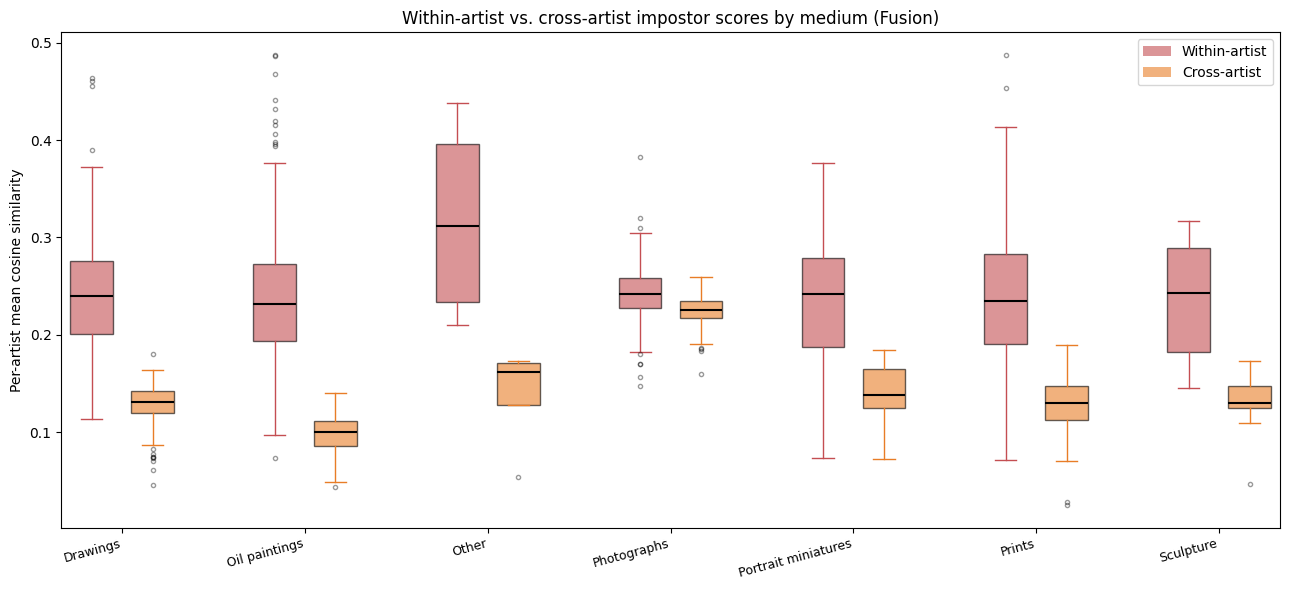

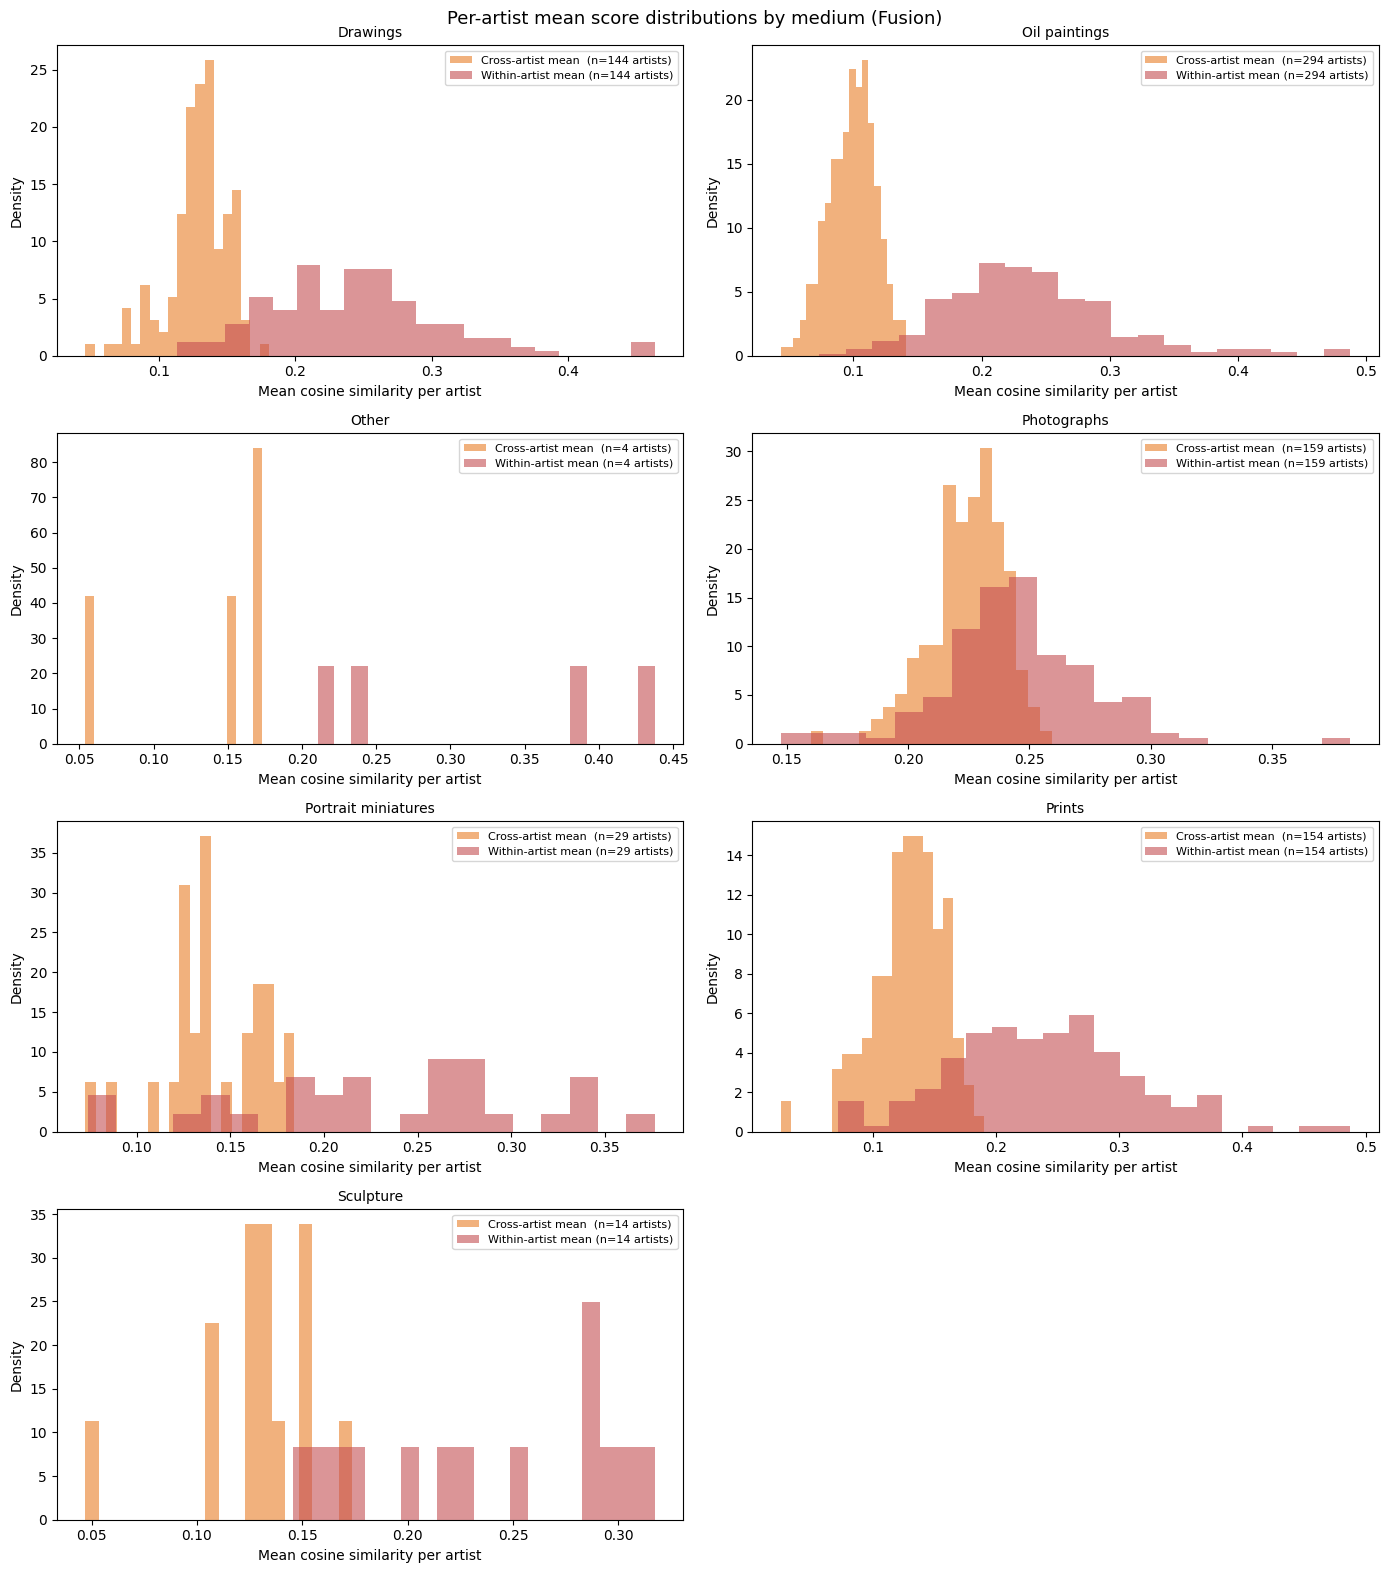

In [105]:
# EXP12: replicate EXP5b (within-artist vs. cross-artist impostor scores, by medium) — Fusion model only
# Reuses within_tagged, cross_tagged_med, score_tagged_pairs, MIN_PAIRS_MED from EXP5b (cell-22).

wt_scores_12, wt_artists_12, wt_mediums_12 = score_tagged_pairs(within_tagged,    emb_fusion)
ct_scores_12, ct_artists_12, ct_mediums_12 = score_tagged_pairs(cross_tagged_med, emb_fusion)

all_media_12 = sorted(set(wt_mediums_12))

# Per-medium analysis
summary_rows_12 = []
medium_data_12  = {}

for medium in all_media_12:
    wm_mask = wt_mediums_12 == medium
    cm_mask = ct_mediums_12 == medium

    w_scores_med  = wt_scores_12[wm_mask]
    w_artists_med = wt_artists_12[wm_mask]
    c_scores_med  = ct_scores_12[cm_mask]
    c_artists_med = ct_artists_12[cm_mask]

    w_means, c_means = [], []
    for aid in np.unique(w_artists_med):
        w_mask = w_artists_med == aid
        c_mask = c_artists_med == aid
        if w_mask.sum() < MIN_PAIRS_MED or c_mask.sum() == 0:
            continue
        w_means.append(float(np.mean(w_scores_med[w_mask])))
        c_means.append(float(np.mean(c_scores_med[c_mask])))

    if len(w_means) < 2:
        continue

    wm     = np.array(w_means)
    cm_arr = np.array(c_means)
    deltas = wm - cm_arr
    stat, p = mannwhitneyu(wm, cm_arr, alternative='greater')

    summary_rows_12.append({
        'Medium':      medium,
        'N artists':   len(wm),
        'Mean within': round(float(np.mean(wm)), 4),
        'Std within':  round(float(np.std(wm)), 4),
        'Mean cross':  round(float(np.mean(cm_arr)), 4),
        'Std cross':   round(float(np.std(cm_arr)), 4),
        'Mean delta':  round(float(np.mean(deltas)), 4),
        'p-value':     round(p, 4),
    })
    medium_data_12[medium] = {'wm': wm, 'cm': cm_arr}

display(pd.DataFrame(summary_rows_12).style.format({
    'Mean within': '{:.4f}', 'Std within': '{:.4f}',
    'Mean cross':  '{:.4f}', 'Std cross':  '{:.4f}',
    'Mean delta':  '{:+.4f}', 'p-value':   '{:.4f}',
    'N artists':   '{:,}',
}))

# Plot 1: grouped boxplot: within vs cross per-artist means, side by side per medium
from matplotlib.patches import Patch

media_list_12 = list(medium_data_12.keys())
positions_w_12, positions_c_12 = [], []
box_w_12, box_c_12 = [], []
for i, medium in enumerate(media_list_12):
    positions_w_12.append(i * 3 + 0.75)
    positions_c_12.append(i * 3 + 1.75)
    box_w_12.append(medium_data_12[medium]['wm'])
    box_c_12.append(medium_data_12[medium]['cm'])

fig, ax = plt.subplots(figsize=(13, 6))
ax.boxplot(box_w_12, positions=positions_w_12, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#C44E52', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#C44E52'), capprops=dict(color='#C44E52'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#C44E52'))
ax.boxplot(box_c_12, positions=positions_c_12, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='#E87D27', alpha=0.6),
           medianprops=dict(color='black', lw=1.5),
           whiskerprops=dict(color='#E87D27'), capprops=dict(color='#E87D27'),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#E87D27'))
ax.set_xticks([i * 3 + 1.25 for i in range(len(media_list_12))])
ax.set_xticklabels(media_list_12, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Per-artist mean cosine similarity')
ax.set_title('Within-artist vs. cross-artist impostor scores by medium (Fusion)')
ax.legend([Patch(facecolor='#C44E52', alpha=0.6), Patch(facecolor='#E87D27', alpha=0.6)],
          ['Within-artist', 'Cross-artist'], fontsize=10)
plt.tight_layout()
plt.show()

# Plot 2: per-medium histograms of per-artist mean scores
ncols = 2
nrows = (len(medium_data_12) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, medium in enumerate(media_list_12):
    ax = axes[i]
    d  = medium_data_12[medium]
    ax.hist(d['cm'], bins=20, density=True, alpha=0.6, color='#E87D27',
            label=f'Cross-artist mean  (n={len(d["cm"])} artists)')
    ax.hist(d['wm'], bins=20, density=True, alpha=0.6, color='#C44E52',
            label=f'Within-artist mean (n={len(d["wm"])} artists)')
    ax.set_title(medium, fontsize=10)
    ax.set_xlabel('Mean cosine similarity per artist')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Per-artist mean score distributions by medium (Fusion)', fontsize=13)
plt.tight_layout()
plt.show()